In [2]:

# CELLULE 1 : CONFIGURATION COLAB + GPU

import torch
import sys
from pathlib import Path

# Vérification GPU
print(f"✅ GPU disponible : {torch.cuda.is_available()}")
print(f"✅ Nom du GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"✅ Mémoire GPU : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB\n")

# Création de l'arborescence projet
PROJECT_ROOT = Path("/content/flickr8k-captioning")
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = DATA_DIR / "Images"

for d in [SRC_DIR, DATA_DIR, IMAGES_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"📁 Créé : {d.relative_to(PROJECT_ROOT)}")

# Ajout au PYTHONPATH
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
    print(f"\n✅ src/ ajouté au PYTHONPATH")

# Seed pour reproductibilité
import random, numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"✅ Seed fixé à {SEED}")

✅ GPU disponible : True
✅ Nom du GPU : Tesla T4
✅ Mémoire GPU : 15.64 GB

📁 Créé : src
📁 Créé : data
📁 Créé : data/Images

✅ src/ ajouté au PYTHONPATH
✅ Seed fixé à 42


In [3]:

# MONTAGE DE GOOGLE DRIVE


from google.colab import drive
import shutil
import zipfile
import os

# Monter Google Drive
print("🔗 Montage de Google Drive...")
drive.mount('/content/drive')
print("✅ Google Drive monté !\n")

# ====== CHEMINS ======
# Chemin vers ton fichier sur Drive
drive_data_path = '/content/drive/MyDrive/Apprentissage/TP2_Groupe3/Data'

# Destination dans Colab
colab_data_path = '/content/data'

# ====== VÉRIFICATION ======
print(f"📍 Recherche de Data dans :\n   {drive_data_path}\n")

# Vérifier si c'est un .zip ou un dossier
if os.path.exists(drive_data_path + '.zip'):
    print("📦 Fichier Data.zip trouvé !")
    print("📂 Extraction en cours...\n")

    with zipfile.ZipFile(drive_data_path + '.zip', 'r') as zip_ref:
        zip_ref.extractall(colab_data_path)

    print("✅ Extraction terminée !")

elif os.path.isdir(drive_data_path):
    print("📁 Dossier Data trouvé (déjà extrait) !")
    print("📂 Copie vers Colab...\n")

    # Copier le dossier
    if os.path.exists(colab_data_path):
        shutil.rmtree(colab_data_path)
    shutil.copytree(drive_data_path, colab_data_path)

    print("✅ Copie terminée !")

else:
    print("❌ Erreur : Data introuvable !")
    print("Vérifie le chemin dans Google Drive.")
    print("\n💡 Structure attendue :")
    print("   Mon Drive/Apprentissage/TP2_Groupe3/Data/")
    print("   ou")
    print("   Mon Drive/Apprentissage/TP2_Groupe3/Data.zip")

# ====== VÉRIFICATION DE LA STRUCTURE ======
print("\n" + "="*60)
print("📁 STRUCTURE DU DATASET")
print("="*60)

if os.path.exists(colab_data_path):
    for root, dirs, files in os.walk(colab_data_path):
        level = root.replace(colab_data_path, '').count(os.sep)
        indent = '  ' * level
        print(f'{indent}📂 {os.path.basename(root)}/')

        # Compter les fichiers
        subindent = '  ' * (level + 1)

        # Afficher quelques exemples
        for i, file in enumerate(files[:3]):
            print(f'{subindent}📄 {file}')

        if len(files) > 3:
            print(f'{subindent}   ... et {len(files) - 3} autres fichiers')

        # Total par dossier
        if files:
            print(f'{subindent}📊 Total : {len(files)} fichiers\n')

print("="*60)

🔗 Montage de Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive monté !

📍 Recherche de Data dans :
   /content/drive/MyDrive/Apprentissage/TP2_Groupe3/Data

📁 Dossier Data trouvé (déjà extrait) !
📂 Copie vers Colab...

✅ Copie terminée !

📁 STRUCTURE DU DATASET
📂 data/
  📄 Flickr_8k.trainImages.txt
  📄 Flickr_8k.testImages.txt
  📄 captions.txt
     ... et 1 autres fichiers
  📊 Total : 4 fichiers

  📂 Images/
    📄 359173181_a75c950aeb.jpg
    📄 2303951441_3c8080907a.jpg
    📄 3224560800_8fefd52510.jpg
       ... et 8088 autres fichiers
    📊 Total : 8091 fichiers



📝 CHARGEMENT DES CAPTIONS
✅ Nombre total de paires (image, caption) : 40,456
✅ Nombre d'images uniques : 8,092
✅ Captions par image : 5.0

📂 SPLITS TRAIN / DEV / TEST
🟢 Train : 6,000 images
🟡 Dev   : 1,000 images
🔴 Test  : 1,000 images
📊 Total : 8,000 images

📊 ANALYSE DES CAPTIONS
📏 Longueur moyenne : 11.8 mots
📏 Longueur médiane : 11 mots
📏 Longueur min : 1 mots
📏 Longueur max : 38 mots
📏 Écart-type : 3.9 mots

📚 Taille du vocabulaire (mots uniques) : 9,181
📚 Nombre total de mots : 476,666

🔤 Top 15 des mots les plus fréquents :
   a               → 61,752 fois
   .               → 34,212 fois
   in              → 18,965 fois
   the             → 18,249 fois
   on              → 10,732 fois
   is              → 9,345 fois
   and             → 8,851 fois
   dog             → 8,126 fois
   with            → 7,761 fois
   man             → 7,238 fois
   of              → 6,712 fois
   two             → 5,224 fois
   white           → 3,935 fois
   black           → 3,825 fois
   boy    

/tmp/ipython-input-2579087638.py:177: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-2579087638.py:177: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


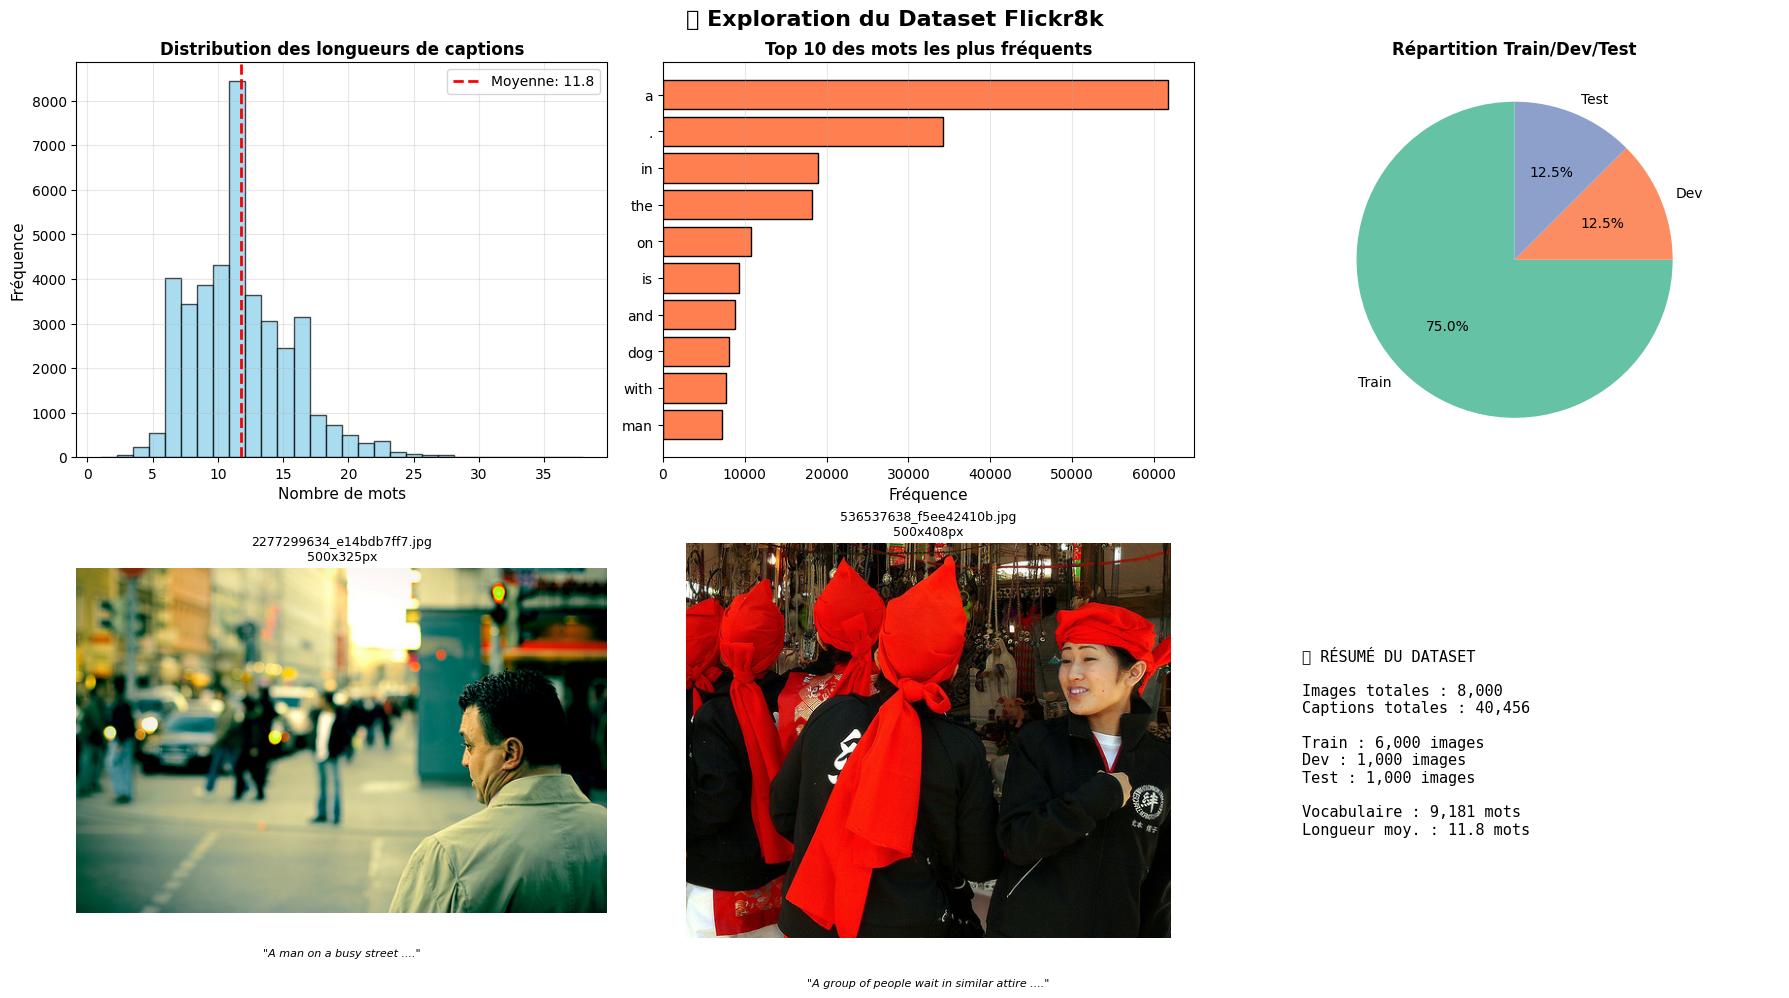


✅ Exploration terminée !

💡 Prochaine étape : Prétraitement des captions (tokenization, vocabulaire)


In [ ]:

#  EXPLORATION DU DATASET FLICKR8K


import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import re
from collections import Counter

# ====== 1. CHARGER LES CAPTIONS ======
print("=" * 70)
print(" CHARGEMENT DES CAPTIONS")
print("=" * 70)

captions_path = '/content/data/captions.txt'

# Parser le fichier (format: image_name.jpg,caption)
captions_data = []
with open(captions_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if ',' in line:
            # Split seulement au premier ','
            parts = line.split(',', 1)
            if len(parts) == 2:
                img_name, caption = parts
                captions_data.append({
                    'image': img_name,
                    'caption': caption
                })

df = pd.DataFrame(captions_data)

print(f"✅ Nombre total de paires (image, caption) : {len(df):,}")
print(f"✅ Nombre d'images uniques : {df['image'].nunique():,}")
print(f"✅ Captions par image : {len(df) / df['image'].nunique():.1f}")
print()

# ====== 2. CHARGER LES SPLITS ======
print("=" * 70)
print(" SPLITS TRAIN / DEV / TEST")
print("=" * 70)

def load_split(filename):
    with open(f'/content/data/{filename}', 'r') as f:
        return set(line.strip() for line in f)

train_images = load_split('Flickr_8k.trainImages.txt')
dev_images = load_split('Flickr_8k.devImages.txt')
test_images = load_split('Flickr_8k.testImages.txt')

print(f"🟢 Train : {len(train_images):,} images")
print(f"🟡 Dev   : {len(dev_images):,} images")
print(f"🔴 Test  : {len(test_images):,} images")
print(f"📊 Total : {len(train_images) + len(dev_images) + len(test_images):,} images")
print()

# ====== 3. ANALYSE DES CAPTIONS ======
print("=" * 70)
print(" ANALYSE DES CAPTIONS")
print("=" * 70)

df['caption_length'] = df['caption'].apply(lambda x: len(x.split()))
df['word_count'] = df['caption'].apply(lambda x: len(x.split()))

print(f" Longueur moyenne : {df['caption_length'].mean():.1f} mots")
print(f" Longueur médiane : {df['caption_length'].median():.0f} mots")
print(f" Longueur min : {df['caption_length'].min()} mots")
print(f" Longueur max : {df['caption_length'].max()} mots")
print(f" Écart-type : {df['caption_length'].std():.1f} mots")
print()

# Vocabulaire total
all_words = []
for caption in df['caption']:
    words = caption.lower().split()
    all_words.extend(words)

vocab_size = len(set(all_words))
print(f"📚 Taille du vocabulaire (mots uniques) : {vocab_size:,}")
print(f"📚 Nombre total de mots : {len(all_words):,}")
print()

# Mots les plus fréquents
word_freq = Counter(all_words)
print("🔤 Top 15 des mots les plus fréquents :")
for word, count in word_freq.most_common(15):
    print(f"   {word:15s} → {count:,} fois")
print()

# ====== 4. EXEMPLES DE CAPTIONS ======
print("=" * 70)
print("EXEMPLES : IMAGES AVEC LEURS 5 CAPTIONS")
print("=" * 70)

# Prendre 2 images au hasard du train set
sample_images = list(train_images)[:2]

for img_name in sample_images:
    print(f"\n🖼️  {img_name}")
    captions_for_img = df[df['image'] == img_name]['caption'].values
    for i, cap in enumerate(captions_for_img, 1):
        print(f"  {i}. {cap}")

# ====== 5. VISUALISATIONS ======
print("\n" + "=" * 70)
print("📊 GÉNÉRATION DES VISUALISATIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🔍 Exploration du Dataset Flickr8k', fontsize=16, fontweight='bold')

# --- Graph 1 : Distribution des longueurs ---
axes[0, 0].hist(df['caption_length'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['caption_length'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["caption_length"].mean():.1f}')
axes[0, 0].set_xlabel('Nombre de mots', fontsize=11)
axes[0, 0].set_ylabel('Fréquence', fontsize=11)
axes[0, 0].set_title('Distribution des longueurs de captions', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# --- Graph 2 : Top mots fréquents ---
top_words = word_freq.most_common(10)
words, counts = zip(*top_words)
axes[0, 1].barh(words, counts, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Fréquence', fontsize=11)
axes[0, 1].set_title('Top 10 des mots les plus fréquents', fontweight='bold')
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis='x', alpha=0.3)

# --- Graph 3 : Répartition des splits ---
splits = ['Train', 'Dev', 'Test']
sizes = [len(train_images), len(dev_images), len(test_images)]
colors = ['#66c2a5', '#fc8d62', '#8da0cb']
axes[0, 2].pie(sizes, labels=splits, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 2].set_title('Répartition Train/Dev/Test', fontweight='bold')

# --- Images 4, 5, 6 : Exemples d'images ---
images_dir = '/content/data/Images/'

for idx, img_name in enumerate(sample_images):
    img_path = os.path.join(images_dir, img_name)

    if os.path.exists(img_path):
        img = Image.open(img_path)
        axes[1, idx].imshow(img)
        axes[1, idx].axis('off')
        axes[1, idx].set_title(f'{img_name}\n{img.size[0]}x{img.size[1]}px', fontsize=9)

        # Afficher la première caption sous l'image
        caption = df[df['image'] == img_name]['caption'].values[0]
        axes[1, idx].text(0.5, -0.1, f'"{caption[:50]}..."',
                         ha='center', va='top', fontsize=8,
                         transform=axes[1, idx].transAxes,
                         style='italic', wrap=True)

# Afficher infos sur la 3ème colonne
axes[1, 2].axis('off')
info_text = f"""
📊 RÉSUMÉ DU DATASET

Images totales : {len(train_images) + len(dev_images) + len(test_images):,}
Captions totales : {len(df):,}

Train : {len(train_images):,} images
Dev : {len(dev_images):,} images
Test : {len(test_images):,} images

Vocabulaire : {vocab_size:,} mots
Longueur moy. : {df['caption_length'].mean():.1f} mots
"""
axes[1, 2].text(0.1, 0.5, info_text, fontsize=11, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.show()

print("\n✅ Exploration terminée !")
print("\n💡 Prochaine étape : Prétraitement des captions (tokenization, vocabulaire)")

In [ ]:

# PRÉTRAITEMENT DES CAPTIONS


import re
import pickle
from collections import Counter
from tqdm import tqdm

print("=" * 70)
print("🧹 NETTOYAGE DES CAPTIONS")
print("=" * 70)

def clean_caption(caption):
    """
    Nettoie une caption :
    - Lowercase
    - Enlève la ponctuation
    - Enlève les caractères spéciaux
    - Enlève les espaces multiples
    """
    # Lowercase
    caption = caption.lower()

    # Enlever la ponctuation
    caption = re.sub(r'[^a-z0-9\s]', '', caption)

    # Enlever les espaces multiples
    caption = re.sub(r'\s+', ' ', caption)

    # Strip
    caption = caption.strip()

    return caption

# Appliquer le nettoyage
print("🔄 Nettoyage en cours...")
df['caption_clean'] = df['caption'].apply(clean_caption)

# Ajouter les tokens <start> et <end>
df['caption_processed'] = df['caption_clean'].apply(
    lambda x: f"<start> {x} <end>"
)

print(" Nettoyage terminé !\n")

# Afficher quelques exemples
print("📝 Exemples AVANT → APRÈS :")
print("-" * 70)
for i in range(3):
    print(f"Original : {df['caption'].iloc[i]}")
    print(f"Nettoyé  : {df['caption_clean'].iloc[i]}")
    print(f"Avec tokens : {df['caption_processed'].iloc[i]}")
    print()

# ====== CONSTRUCTION DU VOCABULAIRE ======
print("=" * 70)
print("📚 CONSTRUCTION DU VOCABULAIRE")
print("=" * 70)

# Collecter tous les mots
all_words = []
for caption in tqdm(df['caption_processed'], desc="📖 Analyse des mots"):
    words = caption.split()
    all_words.extend(words)

# Compter les fréquences
word_freq = Counter(all_words)
print(f"\n✅ Nombre total de mots : {len(all_words):,}")
print(f"✅ Nombre de mots uniques : {len(word_freq):,}")

# Filtrer les mots rares (apparaissant moins de 5 fois)
MIN_WORD_FREQ = 5
filtered_words = {word for word, count in word_freq.items() if count >= MIN_WORD_FREQ}

print(f"✅ Mots après filtrage (freq >= {MIN_WORD_FREQ}) : {len(filtered_words):,}")
print()

# Créer le vocabulaire avec tokens spéciaux
vocab = ['<pad>', '<start>', '<end>', '<unk>'] + sorted(list(filtered_words - {'<start>', '<end>'}))

# Créer les mappings
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

vocab_size = len(vocab)

print(f"📊 Taille finale du vocabulaire : {vocab_size:,}")
print()

# Tokens spéciaux
print("🔑 Tokens spéciaux :")
print(f"   <pad>   → Index {word2idx['<pad>']}")
print(f"   <start> → Index {word2idx['<start>']}")
print(f"   <end>   → Index {word2idx['<end>']}")
print(f"   <unk>   → Index {word2idx['<unk>']}")
print()

# Top mots après nettoyage
print("🔤 Top 20 des mots les plus fréquents (après nettoyage) :")
for word, count in word_freq.most_common(20):
    if word in word2idx:  # Seulement si dans le vocab
        print(f"   {word:15s} → {count:,} fois (idx: {word2idx[word]})")
print()

# ====== ANALYSE DES LONGUEURS APRÈS NETTOYAGE ======
df['processed_length'] = df['caption_processed'].apply(lambda x: len(x.split()))

print("=" * 70)
print("📏 STATISTIQUES DES LONGUEURS (avec <start> et <end>)")
print("=" * 70)
print(f"Longueur moyenne : {df['processed_length'].mean():.1f} mots")
print(f"Longueur médiane : {df['processed_length'].median():.0f} mots")
print(f"Longueur min : {df['processed_length'].min()} mots")
print(f"Longueur max : {df['processed_length'].max()} mots")
print(f"Écart-type : {df['processed_length'].std():.1f} mots")
print()

# Choisir la longueur maximale des séquences
# On prend le 95ème percentile pour couvrir la majorité des captions
MAX_SEQ_LENGTH = int(df['processed_length'].quantile(0.95))
print(f"✅ Longueur maximale choisie (95ème percentile) : {MAX_SEQ_LENGTH} mots")
print(f"   → {(df['processed_length'] <= MAX_SEQ_LENGTH).sum() / len(df) * 100:.1f}% des captions sont couvertes")
print()

# ====== TOKENIZATION ======
print("=" * 70)
print("🔢 TOKENIZATION DES CAPTIONS")
print("=" * 70)

def tokenize_caption(caption, word2idx, max_length):
    """
    Convertit une caption en séquence d'indices
    """
    words = caption.split()

    # Convertir en indices
    tokens = [word2idx.get(word, word2idx['<unk>']) for word in words]

    # Padding ou truncation
    if len(tokens) < max_length:
        # Padding avec <pad>
        tokens += [word2idx['<pad>']] * (max_length - len(tokens))
    else:
        # Truncation
        tokens = tokens[:max_length-1] + [word2idx['<end>']]

    return tokens

# Tokeniser toutes les captions
print("🔄 Tokenisation en cours...")
df['tokens'] = df['caption_processed'].apply(
    lambda x: tokenize_caption(x, word2idx, MAX_SEQ_LENGTH)
)

print("✅ Tokenisation terminée !")
print()

# Exemple de tokenisation
print("📝 Exemple de tokenisation :")
print("-" * 70)
sample_caption = df['caption_processed'].iloc[0]
sample_tokens = df['tokens'].iloc[0]

print(f"Caption : {sample_caption}")
print(f"Tokens  : {sample_tokens[:15]}... (tronqué)")
print(f"Décodé  : {' '.join([idx2word[idx] for idx in sample_tokens[:15]])}...")
print()

# SAUVEGARDER LE VOCABULAIRE
print("=" * 70)
print("SAUVEGARDE DU VOCABULAIRE")
print("=" * 70)

vocab_data = {
    'word2idx': word2idx,
    'idx2word': idx2word,
    'vocab_size': vocab_size,
    'max_seq_length': MAX_SEQ_LENGTH,
    'min_word_freq': MIN_WORD_FREQ
}

with open('/content/vocab.pkl', 'wb') as f:
    pickle.dump(vocab_data, f)

print("✅ Vocabulaire sauvegardé dans : /content/vocab.pkl")
print()

# Sauvegarder le DataFrame
df.to_pickle('/content/captions_processed.pkl')
print("✅ Captions prétraitées sauvegardées dans : /content/captions_processed.pkl")
print()

print("=" * 70)
print("✅ PRÉTRAITEMENT TERMINÉ !")
print("=" * 70)
print(f"📊 Résumé :")
print(f"   - Vocabulaire : {vocab_size:,} mots")
print(f"   - Longueur max : {MAX_SEQ_LENGTH} tokens")
print(f"   - Captions traitées : {len(df):,}")
print(f"   - Images uniques : {df['image'].nunique():,}")

🧹 NETTOYAGE DES CAPTIONS
🔄 Nettoyage en cours...
✅ Nettoyage terminé !

📝 Exemples AVANT → APRÈS :
----------------------------------------------------------------------
Original : caption
Nettoyé  : caption
Avec tokens : <start> caption <end>

Original : A child in a pink dress is climbing up a set of stairs in an entry way .
Nettoyé  : a child in a pink dress is climbing up a set of stairs in an entry way
Avec tokens : <start> a child in a pink dress is climbing up a set of stairs in an entry way <end>

Original : A girl going into a wooden building .
Nettoyé  : a girl going into a wooden building
Avec tokens : <start> a girl going into a wooden building <end>

📚 CONSTRUCTION DU VOCABULAIRE


📖 Analyse des mots: 100%|██████████| 40456/40456 [00:00<00:00, 813157.19it/s]


✅ Nombre total de mots : 517,418
✅ Nombre de mots uniques : 8,831
✅ Mots après filtrage (freq >= 5) : 2,993

📊 Taille finale du vocabulaire : 2,995

🔑 Tokens spéciaux :
   <pad>   → Index 0
   <start> → Index 1
   <end>   → Index 2
   <unk>   → Index 3

🔤 Top 20 des mots les plus fréquents (après nettoyage) :
   a               → 62,986 fois (idx: 11)
   <start>         → 40,456 fois (idx: 1)
   <end>           → 40,456 fois (idx: 2)
   in              → 18,974 fois (idx: 1283)
   the             → 18,418 fois (idx: 2662)
   on              → 10,743 fois (idx: 1714)
   is              → 9,345 fois (idx: 1316)
   and             → 8,851 fois (idx: 60)
   dog             → 8,136 fois (idx: 749)
   with            → 7,765 fois (idx: 2955)
   man             → 7,265 fois (idx: 1524)
   of              → 6,713 fois (idx: 1700)
   two             → 5,638 fois (idx: 2805)
   white           → 3,940 fois (idx: 2932)
   black           → 3,832 fois (idx: 255)
   boy             → 3,581 fois (i

✅ Tokenisation terminée !

📝 Exemple de tokenisation :
----------------------------------------------------------------------
Caption : <start> caption <end>
Tokens  : [1, 3, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]... (tronqué)
Décodé  : <start> <unk> <end> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>...

💾 SAUVEGARDE DU VOCABULAIRE
✅ Vocabulaire sauvegardé dans : /content/vocab.pkl

✅ Captions prétraitées sauvegardées dans : /content/captions_processed.pkl

✅ PRÉTRAITEMENT TERMINÉ !
📊 Résumé :
   - Vocabulaire : 2,995 mots
   - Longueur max : 20 tokens
   - Captions traitées : 40,456
   - Images uniques : 8,092


In [ ]:

# PYTORCH DATASET & DATALOADERS

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import pickle

print("=" * 70)
print("🔧 CONFIGURATION DES TRANSFORMATIONS D'IMAGES")
print("=" * 70)

# Normalisation ImageNet (standard pour ResNet-50)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transformations pour TRAIN (avec augmentation)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transformations pour DEV/TEST
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("✅ Transformations TRAIN : Resize + RandomCrop + Flip + ColorJitter + Normalize")
print("✅ Transformations DEV/TEST : Resize + Normalize")
print()

# ====== DATASET PERSONNALISÉ ======
print("=" * 70)
print(" CRÉATION DU DATASET PERSONNALISÉ")
print("=" * 70)

class Flickr8kDataset(Dataset):
    """
    Dataset personnalisé pour Flickr8k
    """
    def __init__(self, df, images_dir, transform=None):
        """
        Args:
            df: DataFrame avec colonnes ['image', 'caption_processed', 'tokens']
            images_dir: Chemin vers le dossier des images
            transform: Transformations torchvision
        """
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Charger l'image
        img_name = self.df.loc[idx, 'image']
        img_path = f"{self.images_dir}/{img_name}"

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Erreur chargement image {img_path}: {e}")
            # Image par défaut en cas d'erreur
            image = Image.new('RGB', (224, 224), color='black')

        # Appliquer les transformations
        if self.transform:
            image = self.transform(image)

        # Récupérer les tokens
        tokens = torch.tensor(self.df.loc[idx, 'tokens'], dtype=torch.long)

        # Récupérer la caption originale
        caption_text = self.df.loc[idx, 'caption_processed']

        return {
            'image': image,
            'tokens': tokens,
            'caption': caption_text,
            'image_name': img_name
        }

print("✅ Classe Flickr8kDataset créée")
print()

# ====== CHARGER LES DONNÉES PRÉTRAITÉES ======
print("=" * 70)
print("📂 CHARGEMENT DES DONNÉES PRÉTRAITÉES")
print("=" * 70)

# Charger le DataFrame
df = pd.read_pickle('/content/captions_processed.pkl')
print(f"✅ DataFrame chargé : {len(df):,} captions")

# Charger le vocabulaire
with open('/content/vocab.pkl', 'rb') as f:
    vocab_data = pickle.load(f)

word2idx = vocab_data['word2idx']
idx2word = vocab_data['idx2word']
vocab_size = vocab_data['vocab_size']
max_seq_length = vocab_data['max_seq_length']

print(f"✅ Vocabulaire chargé : {vocab_size:,} mots")
print(f"✅ Longueur max : {max_seq_length} tokens")
print()

# ====== CRÉER LES SPLITS ======
print("=" * 70)
print("✂️ CRÉATION DES SPLITS TRAIN / DEV / TEST")
print("=" * 70)

# Charger les listes d'images
def load_image_list(filename):
    with open(f'/content/data/{filename}', 'r') as f:
        return set(line.strip() for line in f)

train_images = load_image_list('Flickr_8k.trainImages.txt')
dev_images = load_image_list('Flickr_8k.devImages.txt')
test_images = load_image_list('Flickr_8k.testImages.txt')

# Filtrer le DataFrame
df_train = df[df['image'].isin(train_images)].reset_index(drop=True)
df_dev = df[df['image'].isin(dev_images)].reset_index(drop=True)
df_test = df[df['image'].isin(test_images)].reset_index(drop=True)

print(f"🟢 Train : {len(df_train):,} captions ({df_train['image'].nunique():,} images)")
print(f"🟡 Dev   : {len(df_dev):,} captions ({df_dev['image'].nunique():,} images)")
print(f"🔴 Test  : {len(df_test):,} captions ({df_test['image'].nunique():,} images)")
print()

# ====== CRÉER LES DATASETS ======
images_dir = '/content/data/Images'

train_dataset = Flickr8kDataset(df_train, images_dir, transform=train_transform)
dev_dataset = Flickr8kDataset(df_dev, images_dir, transform=val_transform)
test_dataset = Flickr8kDataset(df_test, images_dir, transform=val_transform)

print("✅ Datasets créés")
print()

# ====== CRÉER LES DATALOADERS ======
print("=" * 70)
print("🔄 CRÉATION DES DATALOADERS")
print("=" * 70)

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ Train DataLoader : {len(train_loader)} batches de {BATCH_SIZE}")
print(f"✅ Dev DataLoader   : {len(dev_loader)} batches de {BATCH_SIZE}")
print(f"✅ Test DataLoader  : {len(test_loader)} batches de {BATCH_SIZE}")
print()

# ====== TEST DU DATALOADER ======
print("=" * 70)
print("🧪 TEST DU DATALOADER")
print("=" * 70)

# Récupérer un batch
batch = next(iter(train_loader))

print(f"📦 Taille du batch :")
print(f"   Images : {batch['image'].shape}")
print(f"   Tokens : {batch['tokens'].shape}")
print(f"   Nombre de captions : {len(batch['caption'])}")
print()

# Afficher quelques exemples
print("📸 Exemples du batch :")
print("-" * 70)
for i in range(3):
    print(f"\n🖼️  Image #{i+1} : {batch['image_name'][i]}")
    print(f"   Tensor shape : {batch['image'][i].shape}")
    print(f"   Caption : {batch['caption'][i][:60]}...")
    print(f"   Tokens (10 premiers) : {batch['tokens'][i][:10].tolist()}")

    # Décoder les tokens
    decoded = [idx2word[idx.item()] for idx in batch['tokens'][i][:10]]
    print(f"   Décodé : {' '.join(decoded)}")

print()
print("=" * 70)
print("✅ DATASET & DATALOADERS PRÊTS !")
print("=" * 70)

# Résumé final
print(f"""
📊 RÉSUMÉ FINAL :

   Dataset :
   ├─ Train : {len(df_train):,} captions ({df_train['image'].nunique():,} images)
   ├─ Dev   : {len(df_dev):,} captions ({df_dev['image'].nunique():,} images)
   └─ Test  : {len(df_test):,} captions ({df_test['image'].nunique():,} images)

   Vocabulaire :
   ├─ Taille : {vocab_size:,} mots
   ├─ Longueur max : {max_seq_length} tokens
   └─ Tokens spéciaux : <pad>, <start>, <end>, <unk>

   DataLoader :
   ├─ Batch size : {BATCH_SIZE}
   ├─ Train batches : {len(train_loader)}
   ├─ Dev batches : {len(dev_loader)}
   └─ Test batches : {len(test_loader)}

   Transformations :
   ├─ Train : Augmentation (crop, flip, jitter)
   └─ Dev/Test : Resize seulement
""")

print("\n💡 Prochaine étape : Implémentation de l'architecture (Encoder-Decoder)")

🔧 CONFIGURATION DES TRANSFORMATIONS D'IMAGES
✅ Transformations TRAIN : Resize + RandomCrop + Flip + ColorJitter + Normalize
✅ Transformations DEV/TEST : Resize + Normalize

🗂️ CRÉATION DU DATASET PERSONNALISÉ
✅ Classe Flickr8kDataset créée

📂 CHARGEMENT DES DONNÉES PRÉTRAITÉES
✅ DataFrame chargé : 40,456 captions
✅ Vocabulaire chargé : 2,995 mots
✅ Longueur max : 20 tokens

✂️ CRÉATION DES SPLITS TRAIN / DEV / TEST
🟢 Train : 30,000 captions (6,000 images)
🟡 Dev   : 5,000 captions (1,000 images)
🔴 Test  : 5,000 captions (1,000 images)

✅ Datasets créés

🔄 CRÉATION DES DATALOADERS
✅ Train DataLoader : 938 batches de 32
✅ Dev DataLoader   : 157 batches de 32
✅ Test DataLoader  : 157 batches de 32

🧪 TEST DU DATALOADER
📦 Taille du batch :
   Images : torch.Size([32, 3, 224, 224])
   Tokens : torch.Size([32, 20])
   Nombre de captions : 32

📸 Exemples du batch :
----------------------------------------------------------------------

🖼️  Image #1 : 3454754632_977c1523be.jpg
   Tensor shape :

In [ ]:
# ============================================
# 🏗️ ARCHITECTURE TASK A : RESNET-50 + LSTM + ATTENTION
# ============================================

import torch
import torch.nn as nn
import torchvision.models as models

print("=" * 70)
print("🏗️ CONSTRUCTION DE L'ARCHITECTURE - TASK A")
print("=" * 70)

# ====== 1. ENCODER : RESNET-50 ======
class ResNetEncoder(nn.Module):
    """
    Encoder basé sur ResNet-50 préentraîné
    Extrait les features spatiales 7×7×2048
    """
    def __init__(self, pretrained=True):
        super(ResNetEncoder, self).__init__()

        # Charger ResNet-50 préentraîné sur ImageNet
        resnet = models.resnet50(pretrained=pretrained)

        # Enlever les 2 dernières couches (avgpool + fc)

        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)

        # Freeze tous les poids (Task A : pas de fine-tuning)
        for param in self.resnet.parameters():
            param.requires_grad = False

        self.feature_dim = 2048

    def forward(self, images):
        """
        Args:
            images: Tensor de shape (batch_size, 3, 224, 224)
        Returns:
            features: Tensor de shape (batch_size, 2048, 7, 7)
        """
        with torch.no_grad():
            features = self.resnet(images)
        return features

print("✅ ResNetEncoder créé")


# ====== 2. ADDITIVE ATTENTION ======
class AdditiveAttention(nn.Module):
    """
    Mécanisme d'attention additive (Bahdanau Attention)
    """
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        """
        Args:
            encoder_dim: Dimension des features de l'encoder (2048)
            decoder_dim: Dimension du hidden state du LSTM
            attention_dim: Dimension de l'attention
        """
        super(AdditiveAttention, self).__init__()

        # Projection des features de l'encoder
        self.encoder_proj = nn.Linear(encoder_dim, attention_dim)

        # Projection du hidden state du decoder
        self.decoder_proj = nn.Linear(decoder_dim, attention_dim)

        # Couche finale pour calculer le score d'attention
        self.attention = nn.Linear(attention_dim, 1)

        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_features, decoder_hidden):
        """
        Args:
            encoder_features: (batch_size, num_pixels, encoder_dim)
            decoder_hidden: (batch_size, decoder_dim)
        Returns:
            context: (batch_size, encoder_dim) - vecteur de contexte
            alpha: (batch_size, num_pixels) - poids d'attention
        """
        # Projeter les features
        enc_proj = self.encoder_proj(encoder_features)

        # Projeter le hidden state
        dec_proj = self.decoder_proj(decoder_hidden)
        dec_proj = dec_proj.unsqueeze(1)

        # Additive attention : tanh(W_e * e_i + W_d * h_t)
        combined = self.relu(enc_proj + dec_proj)

        # Calculer les scores d'attention
        scores = self.attention(combined)
        scores = scores.squeeze(2)

        # Softmax pour obtenir les poids d'attention
        alpha = self.softmax(scores)

        # Calculer le vecteur de contexte (weighted sum)
        context = (encoder_features * alpha.unsqueeze(2)).sum(dim=1)

        return context, alpha

print("✅ AdditiveAttention créé")


# ====== 3. DECODER : LSTM AVEC ATTENTION ======
class LSTMDecoderWithAttention(nn.Module):
    """
    Decoder LSTM avec mécanisme d'attention
    """
    def __init__(self, vocab_size, embed_dim, encoder_dim, decoder_dim, attention_dim, dropout=0.5):
        """
        Args:
            vocab_size: Taille du vocabulaire
            embed_dim: Dimension des word embeddings
            encoder_dim: Dimension des features de l'encoder (2048)
            decoder_dim: Dimension du LSTM hidden state
            attention_dim: Dimension de l'attention
            dropout: Taux de dropout
        """
        super(LSTMDecoderWithAttention, self).__init__()

        self.vocab_size = vocab_size
        self.encoder_dim = encoder_dim
        self.decoder_dim = decoder_dim

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Attention
        self.attention = AdditiveAttention(encoder_dim, decoder_dim, attention_dim)

        # LSTM cell (input : embedding + context)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)

        # Projection pour initialiser le hidden state h0
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)

        # Couche de sortie
        self.fc = nn.Linear(decoder_dim, vocab_size)

        # Dropout
        self.dropout = nn.Dropout(dropout)

    def init_hidden_state(self, encoder_features):
        """
        Initialise le hidden state à partir des features moyennes
        Args:
            encoder_features: (batch_size, 2048, 7, 7)
        Returns:
            h0, c0: Initial hidden and cell states
        """
        # Mean pooling des features spatiales
        mean_features = encoder_features.mean(dim=[2, 3])

        h0 = self.init_h(mean_features)
        c0 = self.init_c(mean_features)

        return h0, c0

    def forward(self, encoder_features, captions):
        """
        Args:
            encoder_features: (batch_size, 2048, 7, 7)
            captions: (batch_size, max_seq_length) - tokens
        Returns:
            predictions: (batch_size, max_seq_length, vocab_size)
            alphas: (batch_size, max_seq_length, num_pixels) - attention weights
        """
        batch_size = encoder_features.size(0)
        num_pixels = encoder_features.size(2) * encoder_features.size(3)

        # Reshape encoder features : (B, 2048, 7, 7) -> (B, 49, 2048)
        encoder_features = encoder_features.view(batch_size, self.encoder_dim, -1)
        encoder_features = encoder_features.permute(0, 2, 1)

        # Initialiser les hidden states
        h, c = self.init_hidden_state(encoder_features.permute(0, 2, 1).view(batch_size, self.encoder_dim, 7, 7))

        # Longueur de la séquence (on enlève le dernier token pour la prédiction)
        seq_length = captions.size(1) - 1

        # Stocker les prédictions et les attention weights
        predictions = torch.zeros(batch_size, seq_length, self.vocab_size).to(encoder_features.device)
        alphas = torch.zeros(batch_size, seq_length, num_pixels).to(encoder_features.device)

        # Embeddings des captions (sans le dernier token)
        embeddings = self.embedding(captions[:, :-1])

        # Boucle sur chaque timestep
        for t in range(seq_length):
            # Attention
            context, alpha = self.attention(encoder_features, h)

            # Concatener embedding + context
            lstm_input = torch.cat([embeddings[:, t, :], context], dim=1)

            # LSTM step
            h, c = self.lstm_cell(lstm_input, (h, c))

            # Prédiction
            output = self.fc(self.dropout(h))

            # Stocker
            predictions[:, t, :] = output
            alphas[:, t, :] = alpha

        return predictions, alphas

print("✅ LSTMDecoderWithAttention créé")


# ====== 4. MODÈLE COMPLET ======
class ImageCaptioningModel(nn.Module):
    """
    Modèle complet : Encoder + Decoder
    """
    def __init__(self, vocab_size, embed_dim=256, encoder_dim=2048,
                 decoder_dim=512, attention_dim=512, dropout=0.5,
                 pretrained=True):
        super(ImageCaptioningModel, self).__init__()

        self.encoder = ResNetEncoder(pretrained=pretrained)
        self.decoder = LSTMDecoderWithAttention(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            encoder_dim=encoder_dim,
            decoder_dim=decoder_dim,
            attention_dim=attention_dim,
            dropout=dropout
        )

    def forward(self, images, captions):
        """
        Args:
            images: (batch_size, 3, 224, 224)
            captions: (batch_size, max_seq_length)
        Returns:
            predictions: (batch_size, seq_length, vocab_size)
            alphas: (batch_size, seq_length, num_pixels)
        """
        # Encoder
        features = self.encoder(images)  # (B, 2048, 7, 7)

        # Decoder
        predictions, alphas = self.decoder(features, captions)

        return predictions, alphas

print("✅ ImageCaptioningModel créé")
print()

# ====== 5. INSTANCIER LE MODÈLE ======
print("=" * 70)
print(" INSTANCIATION DU MODÈLE - TASK A")
print("=" * 70)

# Hyperparamètres
EMBED_DIM = 256
ENCODER_DIM = 2048
DECODER_DIM = 512
ATTENTION_DIM = 512
DROPOUT = 0.5

# Créer le modèle
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImageCaptioningModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    encoder_dim=ENCODER_DIM,
    decoder_dim=DECODER_DIM,
    attention_dim=ATTENTION_DIM,
    dropout=DROPOUT,
    pretrained=True
).to(device)

print(f"✅ Modèle créé et déplacé sur : {device}")
print()

# ====== 6. COMPTER LES PARAMÈTRES ======
def count_parameters(model):
    """Compte les paramètres trainables et non-trainables"""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total = trainable + non_trainable
    return trainable, non_trainable, total

trainable, non_trainable, total = count_parameters(model)

print("📊 NOMBRE DE PARAMÈTRES :")
print(f"   Trainables     : {trainable:,}")
print(f"   Non-trainables : {non_trainable:,} (ResNet-50 frozen)")
print(f"   Total          : {total:,}")
print()

# Détail par composant
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())

print("📊 PARAMÈTRES PAR COMPOSANT :")
print(f"   Encoder (ResNet-50) : {encoder_params:,} (frozen)")
print(f"   Decoder (LSTM)      : {decoder_params:,} (trainable)")
print()

# ====== 7. TEST DU MODÈLE ======
print("=" * 70)
print(" TEST DU MODÈLE SUR UN BATCH")
print("=" * 70)

model.eval()
with torch.no_grad():
    # Récupérer un batch
    test_batch = next(iter(train_loader))
    test_images = test_batch['image'].to(device)
    test_captions = test_batch['tokens'].to(device)

    print(f"📥 Input shapes :")
    print(f"   Images   : {test_images.shape}")
    print(f"   Captions : {test_captions.shape}")
    print()

    # Forward pass
    predictions, alphas = model(test_images, test_captions)

    print(f"   Output shapes :")
    print(f"   Predictions : {predictions.shape}")
    print(f"   Alphas      : {alphas.shape}")
    print()

    # Vérifier une prédiction
    sample_pred = predictions[0, 0, :]
    predicted_word_idx = torch.argmax(sample_pred).item()
    predicted_word = idx2word[predicted_word_idx]

    print(f"🔍 Exemple de prédiction (1er mot du 1er échantillon) :")
    print(f"   Index prédit : {predicted_word_idx}")
    print(f"   Mot prédit   : '{predicted_word}'")
    print(f"   Mot attendu  : '{idx2word[test_captions[0, 1].item()]}'")

print()
print("=" * 70)
print("✅ ARCHITECTURE TASK A COMPLÈTE ET FONCTIONNELLE !")
print("=" * 70)
print("\n💡 Prochaine étape : Configuration du training (loss, optimizer, scheduler)")

🏗️ CONSTRUCTION DE L'ARCHITECTURE - TASK A
✅ ResNetEncoder créé
✅ AdditiveAttention créé
✅ LSTMDecoderWithAttention créé
✅ ImageCaptioningModel créé

🔧 INSTANCIATION DU MODÈLE - TASK A


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 207MB/s]


✅ Modèle créé et déplacé sur : cuda

📊 NOMBRE DE PARAMÈTRES :
   Trainables     : 11,484,852
   Non-trainables : 23,508,032 (ResNet-50 frozen)
   Total          : 34,992,884

📊 PARAMÈTRES PAR COMPOSANT :
   Encoder (ResNet-50) : 23,508,032 (frozen)
   Decoder (LSTM)      : 11,484,852 (trainable)

🧪 TEST DU MODÈLE SUR UN BATCH
📥 Input shapes :
   Images   : torch.Size([32, 3, 224, 224])
   Captions : torch.Size([32, 20])

📤 Output shapes :
   Predictions : torch.Size([32, 19, 2995])
   Alphas      : torch.Size([32, 19, 49])

🔍 Exemple de prédiction (1er mot du 1er échantillon) :
   Index prédit : 869
   Mot prédit   : 'eyed'
   Mot attendu  : 'a'

✅ ARCHITECTURE TASK A COMPLÈTE ET FONCTIONNELLE !

💡 Prochaine étape : Configuration du training (loss, optimizer, scheduler)


In [ ]:

# CONFIGURATION DU TRAINING - TASK A

import torch.optim as optim
from torch.nn.utils.rnn import pack_padded_sequence
from tqdm import tqdm
import time

print("=" * 70)
print("CONFIGURATION DU TRAINING")
print("=" * 70)

# ====== 1. LOSS FUNCTION ======
# CrossEntropyLoss avec ignore_index pour ignorer le padding
criterion = nn.CrossEntropyLoss(ignore_index=word2idx['<pad>'])

print("✅ Loss function : CrossEntropyLoss (ignore <pad>)")
print()

# ====== 2. OPTIMIZER ======
# Adam optimizer
LEARNING_RATE = 3e-4

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

print(f" Optimizer : Adam (lr={LEARNING_RATE})")
print()

# ====== 3. LEARNING RATE SCHEDULER ======
# ReduceLROnPlateau :
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print("✅ Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)")
print()

# ====== 4. TRAINING CONFIGURATION ======
NUM_EPOCHS = 15
GRAD_CLIP = 5.0
PRINT_FREQ = 100

print(f"📋 Configuration du training :")
print(f"   Epochs : {NUM_EPOCHS}")
print(f"   Gradient clipping : {GRAD_CLIP}")
print(f"   Print frequency : {PRINT_FREQ} batches")
print()

# ====== 5. FONCTIONS UTILITAIRES ======

class AverageMeter:
    """Calcule et stocke la moyenne et la valeur actuelle"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

print(" AverageMeter créé")


def train_epoch(model, dataloader, criterion, optimizer, device, epoch):
    """
    Entraîne le modèle sur une epoch
    """
    model.train()

    losses = AverageMeter()
    batch_time = AverageMeter()

    start = time.time()

    # Barre de progression
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for i, batch in enumerate(pbar):
        images = batch['image'].to(device)
        captions = batch['tokens'].to(device)

        # Forward pass
        predictions, alphas = model(images, captions)

        # Reshape pour le calcul de la loss

        targets = captions[:, 1:]

        # Flatten les prédictions et targets
        predictions = predictions.reshape(-1, vocab_size)
        targets = targets.reshape(-1)

        # Calculer la loss
        loss = criterion(predictions, targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        # Update weights
        optimizer.step()

        # Mise à jour des métriques
        losses.update(loss.item(), images.size(0))
        batch_time.update(time.time() - start)
        start = time.time()

        # Mise à jour de la barre de progression
        pbar.set_postfix({
            'Loss': f'{losses.avg:.4f}',
            'Time': f'{batch_time.avg:.3f}s/batch'
        })

    return losses.avg


def validate(model, dataloader, criterion, device):
    """
    Évalue le modèle sur le dev set
    """
    model.eval()

    losses = AverageMeter()

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            images = batch['image'].to(device)
            captions = batch['tokens'].to(device)

            # Forward pass
            predictions, alphas = model(images, captions)

            # Calcul de la loss
            targets = captions[:, 1:]
            predictions = predictions.reshape(-1, vocab_size)
            targets = targets.reshape(-1)

            loss = criterion(predictions, targets)

            losses.update(loss.item(), images.size(0))

    return losses.avg

print("✅ Fonctions train_epoch et validate créées")
print()

# ====== 6. HISTORIQUE DU TRAINING ======
history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rates': []
}

print(" Historique initialisé")
print()

print("=" * 70)
print(" CONFIGURATION DU TRAINING TERMINÉE !")
print("=" * 70)
print(f"""
📊 RÉCAPITULATIF :

   Modèle : ResNet-50 + LSTM + Attention
   ├─ Paramètres trainables : {trainable:,}
   └─ Paramètres frozen     : {non_trainable:,}

   Training :
   ├─ Epochs    : {NUM_EPOCHS}
   ├─ Optimizer : Adam (lr={LEARNING_RATE})
   ├─ Scheduler : ReduceLROnPlateau
   ├─ Loss      : CrossEntropyLoss
   └─ Grad clip : {GRAD_CLIP}

   Data :
   ├─ Train batches : {len(train_loader)}
   ├─ Dev batches   : {len(dev_loader)}
   └─ Batch size    : {BATCH_SIZE}
""")

print("\n💡 Prochaine étape : Lancer le training !")
print("🚨 Note : Sur T4, chaque epoch ~10-15 min")

⚙️ CONFIGURATION DU TRAINING
✅ Loss function : CrossEntropyLoss (ignore <pad>)

✅ Optimizer : Adam (lr=0.0003)

✅ Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)

📋 Configuration du training :
   Epochs : 15
   Gradient clipping : 5.0
   Print frequency : 100 batches

✅ AverageMeter créé
✅ Fonctions train_epoch et validate créées

✅ Historique initialisé

✅ CONFIGURATION DU TRAINING TERMINÉE !

📊 RÉCAPITULATIF :

   Modèle : ResNet-50 + LSTM + Attention
   ├─ Paramètres trainables : 11,484,852
   └─ Paramètres frozen     : 23,508,032

   Training :
   ├─ Epochs    : 15
   ├─ Optimizer : Adam (lr=0.0003)
   ├─ Scheduler : ReduceLROnPlateau
   ├─ Loss      : CrossEntropyLoss
   └─ Grad clip : 5.0

   Data :
   ├─ Train batches : 938
   ├─ Dev batches   : 157
   └─ Batch size    : 32


💡 Prochaine étape : Lancer le training !
🚨 Note : Sur T4, chaque epoch ~10-15 min


🚀 DÉMARRAGE DU TRAINING


📅 EPOCH 1/15
📊 Learning rate : 0.000300



Epoch 1/15: 100%|██████████| 938/938 [04:27<00:00,  3.50it/s, Loss=4.1292, Time=0.285s/batch]


Validation: 100%|██████████| 157/157 [00:31<00:00,  5.05it/s]



📊 RÉSULTATS EPOCH 1
   Train Loss : 4.1292
   Val Loss   : 3.5652
   LR         : 0.000300
   🎉 Nouveau meilleur modèle ! (val_loss: inf → 3.5652)
   💾 Modèle sauvegardé : /content/best_model_taskA.pth

📅 EPOCH 2/15
📊 Learning rate : 0.000300



Epoch 2/15: 100%|██████████| 938/938 [04:25<00:00,  3.54it/s, Loss=3.4095, Time=0.283s/batch]


...

Validation: 100%|██████████| 157/157 [00:31<00:00,  4.93it/s]



📊 RÉSULTATS EPOCH 14
   Train Loss : 2.3817
   Val Loss   : 2.7653
   LR         : 0.000300
   🎉 Nouveau meilleur modèle ! (val_loss: 2.7730 → 2.7653)
   💾 Modèle sauvegardé : /content/best_model_taskA.pth

📅 EPOCH 15/15
📊 Learning rate : 0.000300



Epoch 15/15: 100%|██████████| 938/938 [04:25<00:00,  3.53it/s, Loss=2.3476, Time=0.283s/batch]


Validation: 100%|██████████| 157/157 [00:30<00:00,  5.07it/s]



📊 RÉSULTATS EPOCH 15
   Train Loss : 2.3476
   Val Loss   : 2.7669
   LR         : 0.000300
   ⏳ Pas d'amélioration (1/5)

✅ TRAINING TERMINÉ !

📊 RÉSUMÉ FINAL :
   
   Meilleure val loss : 2.7653
   Epochs complétées  : 15
   
   Checkpoint sauvegardé :
   └─ /content/best_model_taskA.pth


📈 Génération des courbes d'apprentissage...


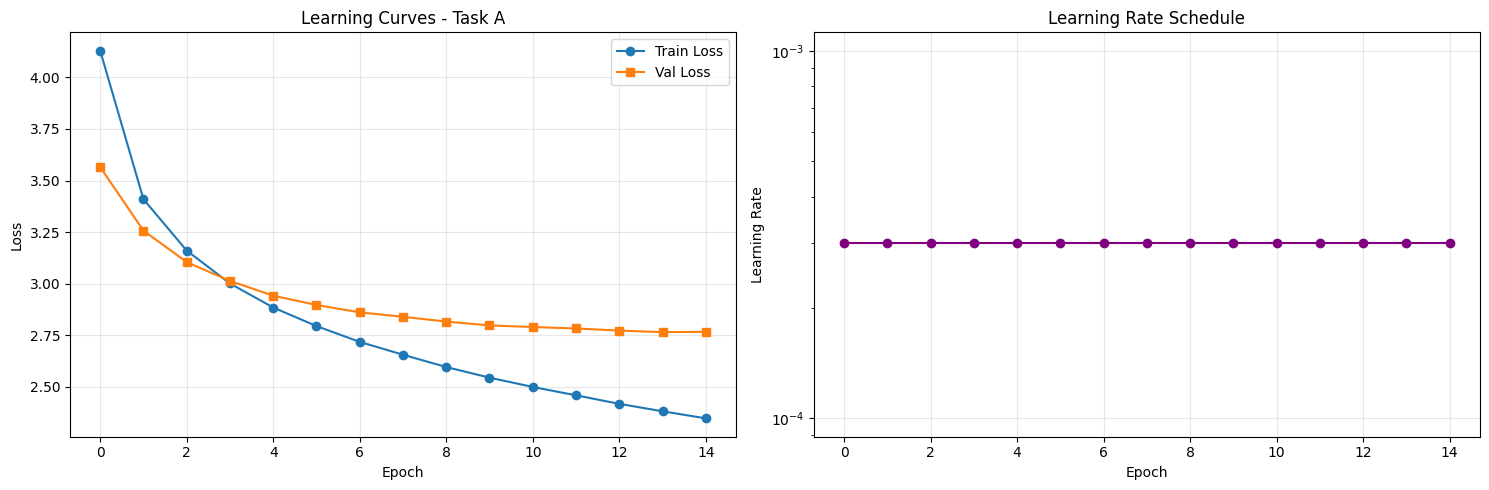

✅ Courbes sauvegardées : /content/training_curves_taskA.png


In [ ]:

# Faisons le TRAINING - TASK A


print("=" * 70)
print(" DÉMARRAGE DU TRAINING")
print("=" * 70)
print()

best_val_loss = float('inf')
patience_counter = 0
EARLY_STOPPING_PATIENCE = 5

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*70}")
    print(f"📅 EPOCH {epoch+1}/{NUM_EPOCHS}")
    print(f"{'='*70}")

    # Learning rate actuel
    current_lr = optimizer.param_groups[0]['lr']
    print(f"📊 Learning rate : {current_lr:.6f}")
    print()

    # Training
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, epoch)

    # Validation
    print()
    val_loss = validate(model, dev_loader, criterion, device)

    # Mise à jour du scheduler
    scheduler.step(val_loss)

    # Sauvegarder l'historique
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rates'].append(current_lr)

    # Afficher les résultats
    print()
    print(f"{'='*70}")
    print(f"📊 RÉSULTATS EPOCH {epoch+1}")
    print(f"{'='*70}")
    print(f"   Train Loss : {train_loss:.4f}")
    print(f"   Val Loss   : {val_loss:.4f}")
    print(f"   LR         : {current_lr:.6f}")

    # Sauvegarder le meilleur modèle
    if val_loss < best_val_loss:
        print(f"   🎉 Nouveau meilleur modèle ! (val_loss: {best_val_loss:.4f} → {val_loss:.4f})")
        best_val_loss = val_loss
        patience_counter = 0

        # Sauvegarder le checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_loss': train_loss,
            'vocab': vocab_data,
            'history': history
        }, '/content/best_model_taskA.pth')

        print(f"   💾 Modèle sauvegardé : /content/best_model_taskA.pth")
    else:
        patience_counter += 1
        print(f" Pas d'amélioration ({patience_counter}/{EARLY_STOPPING_PATIENCE})")

    print(f"{'='*70}")

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\n Early stopping déclenché (patience={EARLY_STOPPING_PATIENCE})")
        break

print()
print("=" * 70)
print("✅ TRAINING TERMINÉ !")
print("=" * 70)
print(f"""
📊 RÉSUMÉ FINAL :

   Meilleure val loss : {best_val_loss:.4f}
   Epochs complétées  : {len(history['train_loss'])}

   Checkpoint sauvegardé :
   └─ /content/best_model_taskA.pth
""")

# ====== VISUALISATION DES COURBES ======
print("\n📈 Génération des courbes d'apprentissage...")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Task A')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Learning rate
axes[1].plot(history['learning_rates'], marker='o', color='purple')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves_taskA.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Courbes sauvegardées : /content/training_curves_taskA.png")

In [ ]:
import shutil
import os

drive_save_path = '/content/drive/MyDrive/Apprentissage/TP2_Groupe3/'
os.makedirs(drive_save_path, exist_ok=True)

# Sauvegarder seulement Task A
shutil.copy('/content/best_model_taskA.pth', f'{drive_save_path}best_model_taskA.pth')
shutil.copy('/content/training_curves_taskA.png', f'{drive_save_path}training_curves_taskA.png')
shutil.copy('/content/vocab.pkl', f'{drive_save_path}vocab.pkl')

print("✅ Task A sauvegardé sur Drive !")

✅ Task A sauvegardé sur Drive !


In [ ]:

#  ARCHITECTURE TASK B : CUSTOM CNN FROM SCRATCH


import torch
import torch.nn as nn

print("=" * 70)
print("🏗️ CONSTRUCTION DE L'ARCHITECTURE - TASK B")
print("=" * 70)

# ====== 1. CUSTOM CNN ENCODER ======
class CustomCNNEncoder(nn.Module):
    """
    CNN custom avec 5 conv layers
    Architecture : 32 → 64 → 128 → 256 → 512
    """
    def __init__(self):
        super(CustomCNNEncoder, self).__init__()

        # 1 : 3 → 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2, 2)  # 224 → 112

        # 2 : 32 → 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2, 2)  # 112 → 56

        # 3 : 64 → 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2, 2)  # 56 → 28

        # 4 : 128 → 256
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU(inplace=True)
        self.pool4 = nn.MaxPool2d(2, 2)

        # 5 : 256 → 512
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512)
        self.relu5 = nn.ReLU(inplace=True)
        self.pool5 = nn.MaxPool2d(2, 2)

        # ✅ GAP Layer
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.feature_dim = 512


    def forward(self, images):
        """
        Args:
            images: (batch_size, 3, 224, 224)
        Returns:
            features: (batch_size, 512, 7, 7)
        """
        x = self.pool1(self.relu1(self.bn1(self.conv1(images))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu4(self.bn4(self.conv4(x))))
        x = self.pool5(self.relu5(self.bn5(self.conv5(x))))
        gap_out = self.gap(x).squeeze(-1).squeeze(-1)

        return x, gap_out

print("✅ CustomCNNEncoder créé")


# ====== 2. ADAPTER LE DECODER POUR ENCODER_DIM=512 ======
# On réutilise LSTMDecoderWithAttention mais avec encoder_dim=512

print("✅ Réutilisation du LSTMDecoderWithAttention (encoder_dim=512)")


# ====== 3. MODÈLE COMPLET TASK B ======
class ImageCaptioningModelCustomCNN(nn.Module):
    """
    Modèle Task B : Custom CNN + LSTM
    """
    def __init__(self, vocab_size, embed_dim=256, encoder_dim=512,
                 decoder_dim=512, attention_dim=512, dropout=0.5):
        super(ImageCaptioningModelCustomCNN, self).__init__()

        self.encoder = CustomCNNEncoder()
        self.decoder = LSTMDecoderWithAttention(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            encoder_dim=encoder_dim,
            decoder_dim=decoder_dim,
            attention_dim=attention_dim,
            dropout=dropout
        )

    def forward(self, images, captions):
        # Encoder
        features, gap_features = self.encoder(images)  # features: (B, 512, 7, 7), gap_features: (B, 512)

        # Decoder
        predictions, alphas = self.decoder(features, captions)

        return predictions, alphas

print("✅ ImageCaptioningModelCustomCNN créé")
print()

# ====== 4. INSTANCIER LE MODÈLE ======
print("=" * 70)
print("🔧 INSTANCIATION DU MODÈLE - TASK B")
print("=" * 70)

# Hyperparamètres
EMBED_DIM = 256
ENCODER_DIM = 512
DECODER_DIM = 512
ATTENTION_DIM = 512
DROPOUT = 0.5

# Créer le modèle
model_custom = ImageCaptioningModelCustomCNN(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    encoder_dim=ENCODER_DIM,
    decoder_dim=DECODER_DIM,
    attention_dim=ATTENTION_DIM,
    dropout=DROPOUT
).to(device)

print(f"✅ Modèle créé et déplacé sur : {device}")
print()

# ====== 5. COMPTER LES PARAMÈTRES ======
trainable_custom, non_trainable_custom, total_custom = count_parameters(model_custom)

print("📊 NOMBRE DE PARAMÈTRES :")
print(f"   Trainables     : {trainable_custom:,}")
print(f"   Non-trainables : {non_trainable_custom:,}")
print(f"   Total          : {total_custom:,}")
print()

# Détail par composant
encoder_params_custom = sum(p.numel() for p in model_custom.encoder.parameters())
decoder_params_custom = sum(p.numel() for p in model_custom.decoder.parameters())

print("📊 PARAMÈTRES PAR COMPOSANT :")
print(f"   Encoder (Custom CNN) : {encoder_params_custom:,} (trainable)")
print(f"   Decoder (LSTM)       : {decoder_params_custom:,} (trainable)")
print()

# ====== 6. COMPARAISON TASK A vs TASK B ======
print("=" * 70)
print("📊 COMPARAISON TASK A vs TASK B")
print("=" * 70)

print(f"""
{'Metric':<30} {'Task A (ResNet-50)':<25} {'Task B (Custom CNN)':<25}
{'-'*80}
{'Total Parameters':<30} {f'{total:,}':<25} {f'{total_custom:,}':<25}
{'Trainable Parameters':<30} {f'{trainable:,}':<25} {f'{trainable_custom:,}':<25}
{'Encoder Parameters':<30} {f'{encoder_params:,}':<25} {f'{encoder_params_custom:,}':<25}
{'Encoder Trainable':<30} {'No (frozen)':<25} {'Yes (end-to-end)':<25}
""")

print()

# ====== 7. TEST DU MODÈLE ======
print("=" * 70)
print("🧪 TEST DU MODÈLE SUR UN BATCH")
print("=" * 70)

model_custom.eval()
with torch.no_grad():
    test_batch = next(iter(train_loader))
    test_images = test_batch['image'].to(device)
    test_captions = test_batch['tokens'].to(device)

    print(f"📥 Input shapes :")
    print(f"   Images   : {test_images.shape}")
    print(f"   Captions : {test_captions.shape}")
    print()

    # Forward pass
    predictions_custom, alphas_custom = model_custom(test_images, test_captions)

    print(f"📤 Output shapes :")
    print(f"   Predictions : {predictions_custom.shape}")
    print(f"   Alphas      : {alphas_custom.shape}")
    print()

    sample_pred = predictions_custom[0, 0, :]
    predicted_word_idx = torch.argmax(sample_pred).item()
    predicted_word = idx2word[predicted_word_idx]

    print(f"🔍 Exemple de prédiction (1er mot) :")
    print(f"   Mot prédit   : '{predicted_word}'")
    print(f"   Mot attendu  : '{idx2word[test_captions[0, 1].item()]}'")

print()
print("=" * 70)
print("✅ ARCHITECTURE TASK B COMPLÈTE ET FONCTIONNELLE !")
print("=" * 70)
print("\n💡 Prochaine étape : Training du Custom CNN")

🏗️ CONSTRUCTION DE L'ARCHITECTURE - TASK B
✅ CustomCNNEncoder créé
✅ Réutilisation du LSTMDecoderWithAttention (encoder_dim=512)
✅ ImageCaptioningModelCustomCNN créé

🔧 INSTANCIATION DU MODÈLE - TASK B
✅ Modèle créé et déplacé sur : cuda

📊 NOMBRE DE PARAMÈTRES :
   Trainables     : 7,550,388
   Non-trainables : 0
   Total          : 7,550,388

📊 PARAMÈTRES PAR COMPOSANT :
   Encoder (Custom CNN) : 1,570,560 (trainable)
   Decoder (LSTM)       : 5,979,828 (trainable)

📊 COMPARAISON TASK A vs TASK B

Metric                         Task A (ResNet-50)        Task B (Custom CNN)      
--------------------------------------------------------------------------------
Total Parameters               34,992,884                7,550,388                
Trainable Parameters           11,484,852                7,550,388                
Encoder Parameters             23,508,032                1,570,560                
Encoder Trainable              No (frozen)               Yes (end-to-end)         

✅ Loss : CrossEntropyLoss
✅ Optimizer : Adam (lr=0.0005)
✅ Scheduler : ReduceLROnPlateau

📋 Configuration :
   Epochs : 20
   Gradient clipping : 5.0
   Learning rate : 0.0005

✅ Historique initialisé

✅ Configuration terminée

🚀 DÉMARRAGE DU TRAINING - TASK B


📅 EPOCH 1/20
📊 Learning rate : 0.000500



Epoch 1/20: 100%|██████████| 938/938 [04:19<00:00,  3.61it/s, Loss=3.9848, Time=0.277s]


Validation: 100%|██████████| 157/157 [00:27<00:00,  5.68it/s]



📊 RÉSULTATS EPOCH 1
   Train Loss : 3.9848
   Val Loss   : 3.4895
   LR         : 0.000500
   🎉 Nouveau meilleur ! (val_loss: inf → 3.4895)
   💾 Sauvegardé : best_model_taskB.pth

📅 EPOCH 2/20
📊 Learning rate : 0.000500



Epoch 2/20: 100%|██████████| 938/938 [04:18<00:00,  3.62it/s, Loss=3.3588, Time=0.276s]


...

Validation: 100%|██████████| 157/157 [00:27<00:00,  5.78it/s]



📊 RÉSULTATS EPOCH 17
   Train Loss : 2.0946
   Val Loss   : 2.9444
   LR         : 0.000500
   ⏳ Pas d'amélioration (4/5)

📅 EPOCH 18/20
📊 Learning rate : 0.000250



Epoch 18/20: 100%|██████████| 938/938 [04:15<00:00,  3.67it/s, Loss=1.9836, Time=0.273s]


Validation: 100%|██████████| 157/157 [00:27<00:00,  5.67it/s]



📊 RÉSULTATS EPOCH 18
   Train Loss : 1.9836
   Val Loss   : 2.9515
   LR         : 0.000250
   ⏳ Pas d'amélioration (5/5)

🛑 Early stopping (patience=5)

✅ TRAINING TASK B TERMINÉ !

📊 RÉSUMÉ :
   Meilleure val loss : 2.8924
   Epochs : 18
   Checkpoint : /content/best_model_taskB.pth


📈 Génération des courbes...


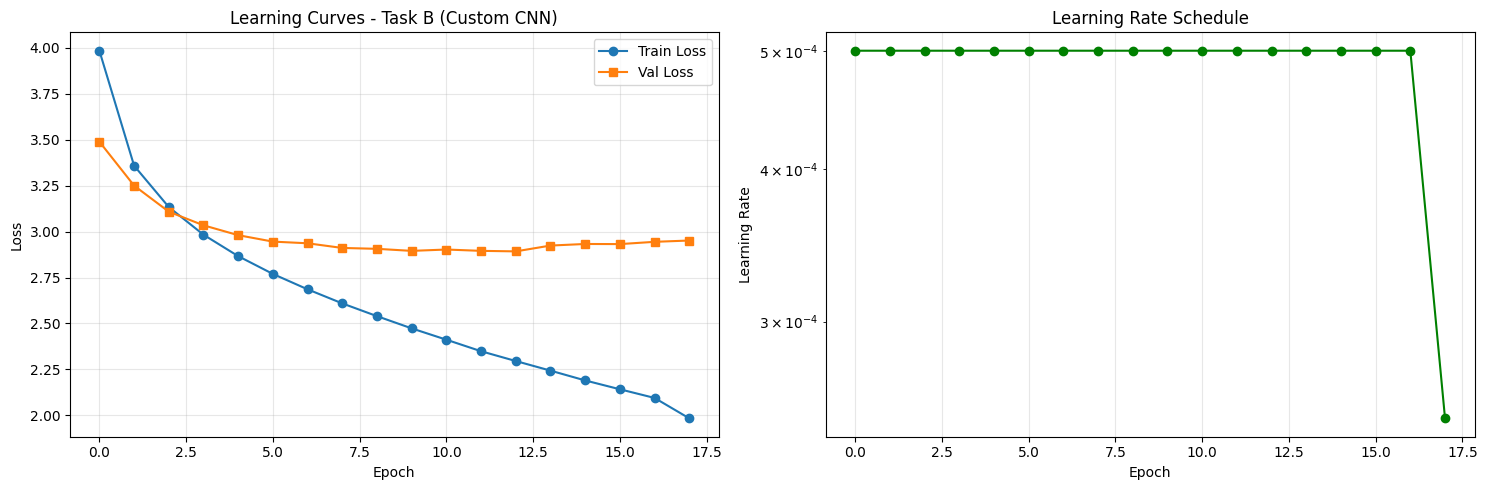

✅ Courbes : training_curves_taskB.png


In [ ]:
# ============================================
# CONFIGURATION + TRAINING - TASK B
# ============================================
# CONFIGURATION + TRAINING - TASK B
# ============================================

import torch.optim as optim
import time
from tqdm import tqdm

# UTILITAIRES
class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.val=0; self.avg=0; self.sum=0; self.count=0
    def update(self, val, n=1): self.sum+=val*n; self.count+=n; self.avg=self.sum/self.count

def validate(model, dataloader, criterion, device):
    model.eval()
    losses = AverageMeter()
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            images = batch['image'].to(device)
            captions = batch['tokens'].to(device)
            predictions, alphas = model(images, captions)
            targets = captions[:, 1:]
            predictions = predictions.reshape(-1, vocab_size)
            targets = targets.reshape(-1)
            loss = criterion(predictions, targets)
            losses.update(loss.item(), images.size(0))
    return losses.avg

def train_epoch_custom(model, dataloader, criterion, optimizer, device, epoch, num_epochs):
    model.train()
    losses = AverageMeter()
    batch_time = AverageMeter()
    start = time.time()
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for i, batch in enumerate(pbar):
        images = batch['image'].to(device)
        captions = batch['tokens'].to(device)
        predictions, alphas = model(images, captions)
        targets = captions[:, 1:]
        predictions = predictions.reshape(-1, vocab_size)
        targets = targets.reshape(-1)
        loss = criterion(predictions, targets)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_CUSTOM)
        optimizer.step()
        losses.update(loss.item(), images.size(0))
        batch_time.update(time.time() - start)
        start = time.time()
        pbar.set_postfix({'Loss': f'{losses.avg:.4f}', 'Time': f'{batch_time.avg:.3f}s'})
    return losses.avg

# ====== 1. LOSS & OPTIMIZER ======
criterion_custom = nn.CrossEntropyLoss(ignore_index=word2idx['<pad>'])

# Learning rate légèrement plus élevé (modèle plus petit)
LEARNING_RATE_CUSTOM = 5e-4

optimizer_custom = optim.Adam(
    model_custom.parameters(),
    lr=LEARNING_RATE_CUSTOM
)

print(f"✅ Loss : CrossEntropyLoss")
print(f"✅ Optimizer : Adam (lr={LEARNING_RATE_CUSTOM})")

# ====== 2. SCHEDULER ======
scheduler_custom = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_custom,
    mode='min',
    factor=0.5,
    patience=3
)

print(f"✅ Scheduler : ReduceLROnPlateau")
print()

# ====== 3. HYPERPARAMÈTRES ======
NUM_EPOCHS_CUSTOM = 20  # Plus d'epochs car from scratch
GRAD_CLIP_CUSTOM = 5.0

print(f"📋 Configuration :")
print(f"   Epochs : {NUM_EPOCHS_CUSTOM}")
print(f"   Gradient clipping : {GRAD_CLIP_CUSTOM}")
print(f"   Learning rate : {LEARNING_RATE_CUSTOM}")
print()

# ====== 4. HISTORIQUE ======
history_custom = {
    'train_loss': [],
    'val_loss': [],
    'learning_rates': []
}

print("✅ Historique initialisé")
print()

# 5. FONCTIONS DE TRAINING (réutilisées)
def train_epoch_custom(model, dataloader, criterion, optimizer, device, epoch, num_epochs):
    model.train()
    losses = AverageMeter()
    batch_time = AverageMeter()
    start = time.time()

    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for i, batch in enumerate(pbar):
        images = batch['image'].to(device)
        captions = batch['tokens'].to(device)

        predictions, alphas = model(images, captions)

        targets = captions[:, 1:]
        predictions = predictions.reshape(-1, vocab_size)
        targets = targets.reshape(-1)
        loss = criterion(predictions, targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_CUSTOM)
        optimizer.step()

        losses.update(loss.item(), images.size(0))
        batch_time.update(time.time() - start)
        start = time.time()

        pbar.set_postfix({
            'Loss': f'{losses.avg:.4f}',
            'Time': f'{batch_time.avg:.3f}s'
        })

    return losses.avg

print("✅ Configuration terminée")
print()

#  DÉMARRAGE DU TRAINING - TASK B

print("=" * 70)
print("🚀 DÉMARRAGE DU TRAINING - TASK B")
print("=" * 70)
print()

best_val_loss_custom = float('inf')
patience_counter_custom = 0
EARLY_STOPPING_PATIENCE_CUSTOM = 5

for epoch in range(NUM_EPOCHS_CUSTOM):
    print(f"\n{'='*70}")
    print(f"📅 EPOCH {epoch+1}/{NUM_EPOCHS_CUSTOM}")
    print(f"{'='*70}")

    current_lr = optimizer_custom.param_groups[0]['lr']
    print(f"📊 Learning rate : {current_lr:.6f}\n")

    # Training
    train_loss = train_epoch_custom(
        model_custom, train_loader, criterion_custom,
        optimizer_custom, device, epoch, NUM_EPOCHS_CUSTOM
    )

    # Validation
    print()
    val_loss = validate(model_custom, dev_loader, criterion_custom, device)

    # Scheduler
    scheduler_custom.step(val_loss)

    # Historique
    history_custom['train_loss'].append(train_loss)
    history_custom['val_loss'].append(val_loss)
    history_custom['learning_rates'].append(current_lr)

    # Résultats
    print(f"\n{'='*70}")
    print(f"📊 RÉSULTATS EPOCH {epoch+1}")
    print(f"{'='*70}")
    print(f"   Train Loss : {train_loss:.4f}")
    print(f"   Val Loss   : {val_loss:.4f}")
    print(f"   LR         : {current_lr:.6f}")

    # Sauvegarder le meilleur
    if val_loss < best_val_loss_custom:
        print(f"   🎉 Nouveau meilleur ! (val_loss: {best_val_loss_custom:.4f} → {val_loss:.4f})")
        best_val_loss_custom = val_loss
        patience_counter_custom = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model_custom.state_dict(),
            'optimizer_state_dict': optimizer_custom.state_dict(),
            'val_loss': val_loss,
            'train_loss': train_loss,
            'vocab': vocab_data,
            'history': history_custom
        }, '/content/best_model_taskB.pth')

        print(f"   💾 Sauvegardé : best_model_taskB.pth")
    else:
        patience_counter_custom += 1
        print(f"   ⏳ Pas d'amélioration ({patience_counter_custom}/{EARLY_STOPPING_PATIENCE_CUSTOM})")

    print(f"{'='*70}")

    # Early stopping
    if patience_counter_custom >= EARLY_STOPPING_PATIENCE_CUSTOM:
        print(f"\n Early stopping (patience={EARLY_STOPPING_PATIENCE_CUSTOM})")
        break

print()
print("=" * 70)
print(" TRAINING TASK B TERMINÉ !")
print("=" * 70)
print(f"""
📊 RÉSUMÉ :
   Meilleure val loss : {best_val_loss_custom:.4f}
   Epochs : {len(history_custom['train_loss'])}
   Checkpoint : /content/best_model_taskB.pth
""")

# COURBES
print("\n📈 Génération des courbes...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history_custom['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history_custom['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curves - Task B (Custom CNN)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# LR
axes[1].plot(history_custom['learning_rates'], marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')
axes[1].set_yscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves_taskB.png', dpi=150)
plt.show()

print(" Courbes : training_curves_taskB.png")

In [ ]:

# 💾 SAUVEGARDER TASK B SUR GOOGLE DRIVE


import shutil
import os

drive_save_path = '/content/drive/MyDrive/Apprentissage/TP2_Groupe3/'

# Sauvegarder le modèle Task B
shutil.copy('/content/best_model_taskB.pth',
            f'{drive_save_path}best_model_taskB.pth')
print(f"✅ Modèle Task B sauvegardé")

# Sauvegarder les courbes Task B  ← fichier source corrigé
shutil.copy('/content/training_curves_taskB.png',
            f'{drive_save_path}training_curves_taskB.png')
print(f" Courbes Task B sauvegardées")

print()
print("=" * 70)
print(" TASK B SAUVEGARDÉ SUR DRIVE !")
print("=" * 70)
print(f"\n Fichiers dans : {drive_save_path}")
print(f"   - best_model_taskA.pth")
print(f"   - best_model_taskB.pth")
print(f"   - training_curves_taskA.png")
print(f"   - training_curves_taskB.png")
print(f"   - vocab.pkl")

✅ Modèle Task B sauvegardé
✅ Courbes Task B sauvegardées

✅ TASK B SAUVEGARDÉ SUR DRIVE !

📁 Fichiers dans : /content/drive/MyDrive/Apprentissage/TP2_Groupe3/
   - best_model_taskA.pth
   - best_model_taskB.pth
   - training_curves_taskA.png
   - training_curves_taskB.png
   - vocab.pkl


In [ ]:

# COMPARAISON FINALE TASK A vs TASK B


print("=" * 70)
print("📊 COMPARAISON FINALE DES DEUX MODÈLES")
print("=" * 70)

comparison = f"""
{'Métrique':<30} {'Task A (ResNet-50)':<20} {'Task B (Custom CNN)':<20}
{'-'*70}
{'Val Loss (meilleure)':<30} {'2.7653':<20} {'2.8924':<20}
{'Train Loss (meilleure epoch)':<30} {'2.35':<20} {'2.2955':<20}
{'Gap Train/Val':<30} {'0.42':<20} {'0.60':<20}
{'Epochs complétées':<30} {'15':<20} {'18':<20}
{'Temps total':<30} {'~67 min':<20} {'~75 min':<20}

{'Paramètres totaux':<30} {'34.9M':<20} {'7.5M':<20}
{'Paramètres trainables':<30} {'11.5M':<20} {'7.5M':<20}
{'Paramètres frozen':<30} {'23.5M':<20} {'0':<20}

{'Encoder':<30} {'ResNet-50 (ImageNet)':<20} {'Custom CNN (scratch)':<20}
{'Encoder dim':<30} {'2048':<20} {'512':<20}
{'Fine-tuning encoder':<30} {'Non':<20} {'Oui (end-to-end)':<20}
"""

print(comparison)

print("\n🏆 GAGNANT : Task A (ResNet-50)")
print("   └─ Val loss : 2.7653 < 2.8924")
print("   └─ Écart : +0.13 (4.7% moins bon pour Task B)")
print()

print("💡 OBSERVATIONS :")
print("   ✅ ResNet-50 préentraîné surpasse le Custom CNN from scratch")
print("   ✅ Transfer learning efficace même avec encoder frozen")
print("   ✅ Custom CNN montre de l'overfitting (gap train/val = 0.60 vs 0.42)")
print("   ✅ ResNet-50 généralise mieux (gap train/val = 0.42)")

📊 COMPARAISON FINALE DES DEUX MODÈLES

Métrique                       Task A (ResNet-50)   Task B (Custom CNN) 
----------------------------------------------------------------------
Val Loss (meilleure)           2.7653               2.8924              
Train Loss (meilleure epoch)   2.35                 2.2955              
Gap Train/Val                  0.42                 0.60                
Epochs complétées              15                   18                  
Temps total                    ~67 min              ~75 min             

Paramètres totaux              34.9M                7.5M                
Paramètres trainables          11.5M                7.5M                
Paramètres frozen              23.5M                0                   

Encoder                        ResNet-50 (ImageNet) Custom CNN (scratch)
Encoder dim                    2048                 512                 
Fine-tuning encoder            Non                  Oui (end-to-end)    


🏆 GAGNANT 

In [ ]:

#  FONCTION DE GÉNÉRATION DE CAPTIONS

import torch
import torch.nn.functional as F

print("=" * 70)
print("🔧 CRÉATION DES FONCTIONS DE GÉNÉRATION")
print("=" * 70)

def generate_caption(model, image, word2idx, idx2word, max_length=20, device='cuda'):
    model.eval()

    with torch.no_grad():
        image = image.to(device)

        # Gérer Task A (tensor) et Task B (tuple)
        encoder_output = model.encoder(image)
        if isinstance(encoder_output, tuple):
            features = encoder_output[0]
        else:
            features = encoder_output

        batch_size = features.size(0)
        encoder_dim = features.size(1)
        num_pixels = features.size(2) * features.size(3)

        features = features.view(batch_size, encoder_dim, -1)
        features = features.permute(0, 2, 1)

        h, c = model.decoder.init_hidden_state(
            features.permute(0, 2, 1).view(batch_size, encoder_dim, 7, 7)
        )

        word = torch.tensor([word2idx['<start>']]).to(device)
        caption = []
        alphas_list = []

        for step in range(max_length):
            embeddings = model.decoder.embedding(word)
            context, alpha = model.decoder.attention(features, h)
            alphas_list.append(alpha.cpu().numpy())
            lstm_input = torch.cat([embeddings, context], dim=1)
            h, c = model.decoder.lstm_cell(lstm_input, (h, c))
            output = model.decoder.fc(h)
            predicted_idx = output.argmax(1).item()
            predicted_word = idx2word[predicted_idx]

            if predicted_word == '<end>':
                break

            caption.append(predicted_word)
            word = torch.tensor([predicted_idx]).to(device)

        return caption, alphas_list

print(" Fonction generate_caption créée")


def generate_caption_beam_search(model, image, word2idx, idx2word, beam_size=3, max_length=20, device='cuda'):
    model.eval()

    with torch.no_grad():
        image = image.to(device)

        # Gérer Task A (tensor) et Task B (tuple)
        encoder_output = model.encoder(image)
        if isinstance(encoder_output, tuple):
            features = encoder_output[0]
        else:
            features = encoder_output

        batch_size = features.size(0)
        encoder_dim = features.size(1)

        features = features.view(batch_size, encoder_dim, -1).permute(0, 2, 1)

        h, c = model.decoder.init_hidden_state(
            features.permute(0, 2, 1).view(batch_size, encoder_dim, 7, 7)
        )

        features = features.expand(beam_size, *features.shape[1:])

        start_token = word2idx['<start>']
        sequences = [[start_token]]
        scores = [0.0]
        complete_sequences = []
        complete_scores = []

        for step in range(max_length):
            all_candidates = []

            for i, seq in enumerate(sequences):
                if seq[-1] == word2idx['<end>']:
                    complete_sequences.append(seq)
                    complete_scores.append(scores[i])
                    continue

                word = torch.tensor([seq[-1]]).to(device)
                embeddings = model.decoder.embedding(word)
                context, _ = model.decoder.attention(features[i:i+1], h[i:i+1] if step > 0 else h)
                lstm_input = torch.cat([embeddings, context], dim=1)
                h_new, c_new = model.decoder.lstm_cell(lstm_input, (h[i:i+1] if step > 0 else h, c[i:i+1] if step > 0 else c))
                output = model.decoder.fc(h_new)
                log_probs = F.log_softmax(output, dim=1)
                top_log_probs, top_indices = log_probs.topk(beam_size)

                for j in range(beam_size):
                    candidate_seq = seq + [top_indices[0, j].item()]
                    candidate_score = scores[i] + top_log_probs[0, j].item()
                    all_candidates.append((candidate_score, candidate_seq))

            all_candidates.sort(reverse=True, key=lambda x: x[0])
            sequences = [seq for score, seq in all_candidates[:beam_size]]
            scores = [score for score, seq in all_candidates[:beam_size]]

            if len(complete_sequences) >= beam_size:
                break

        for seq, score in zip(sequences, scores):
            if seq not in complete_sequences:
                complete_sequences.append(seq)
                complete_scores.append(score)

        best_idx = complete_scores.index(max(complete_scores))
        best_sequence = complete_sequences[best_idx]
        caption = [idx2word[idx] for idx in best_sequence[1:] if idx2word[idx] not in ['<start>', '<end>', '<pad>']]

        return caption, []

print("Fonction generate_caption_beam_search créée")
print()
print("=" * 70)
print(" FONCTIONS DE GÉNÉRATION PRÊTES !")
print("=" * 70)

🔧 CRÉATION DES FONCTIONS DE GÉNÉRATION
✅ Fonction generate_caption créée
✅ Fonction generate_caption_beam_search créée

✅ FONCTIONS DE GÉNÉRATION PRÊTES !


In [ ]:

# CALCUL DES BLEU SCORES - TASK D


import torch
import pickle
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu
from tqdm import tqdm
import numpy as np

# ✅ Ajout device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
drive_path = '/content/drive/MyDrive/Apprentissage/TP2_Groupe3/'

print("=" * 70)
print("📊 ÉVALUATION QUANTITATIVE - BLEU SCORES")
print("=" * 70)

def evaluate_bleu_scores(model, dataloader, word2idx, idx2word, device, max_samples=None):
    model.eval()
    references_all = []
    hypotheses_all = []

    with torch.no_grad():
        samples_processed = 0
        for batch in tqdm(dataloader, desc="Génération captions"):
            images = batch['image'].to(device)
            captions_text = batch['caption']

            for i in range(images.size(0)):
                image = images[i:i+1]
                generated_caption, _ = generate_caption(
                    model, image, word2idx, idx2word, device=device
                )
                reference = captions_text[i].replace('<start>', '').replace('<end>', '').strip().split()
                references_all.append([reference])
                hypotheses_all.append(generated_caption)
                samples_processed += 1
                if max_samples and samples_processed >= max_samples:
                    break

            if max_samples and samples_processed >= max_samples:
                break

    bleu1 = corpus_bleu(references_all, hypotheses_all, weights=(1.0, 0, 0, 0))
    bleu2 = corpus_bleu(references_all, hypotheses_all, weights=(0.5, 0.5, 0, 0))
    bleu3 = corpus_bleu(references_all, hypotheses_all, weights=(0.33, 0.33, 0.33, 0))
    bleu4 = corpus_bleu(references_all, hypotheses_all, weights=(0.25, 0.25, 0.25, 0.25))

    return {
        'BLEU-1': bleu1,
        'BLEU-2': bleu2,
        'BLEU-3': bleu3,
        'BLEU-4': bleu4
    }, references_all, hypotheses_all

print(" Fonction evaluate_bleu_scores créée")
print()

# ====== CHARGER LES MODÈLES ======
print("=" * 70)
print(" CHARGEMENT DES MODÈLES")
print("=" * 70)

checkpoint_A = torch.load(f'{drive_path}best_model_taskA.pth', map_location=device)
model.load_state_dict(checkpoint_A['model_state_dict'])
print(f" Task A chargé (epoch {checkpoint_A['epoch']}, val_loss={checkpoint_A['val_loss']:.4f})")

checkpoint_B = torch.load(f'{drive_path}best_model_taskB.pth', map_location=device)
model_custom.load_state_dict(checkpoint_B['model_state_dict'])
print(f"Task B chargé (epoch {checkpoint_B['epoch']}, val_loss={checkpoint_B['val_loss']:.4f})")
print()

#  ÉVALUER SUR LE TEST SET
print("=" * 70)
print(" ÉVALUATION SUR LE TEST SET")
print("=" * 70)

print("\n TASK A - ResNet-50 + LSTM")
print("-" * 70)
bleu_scores_A, refs_A, hyps_A = evaluate_bleu_scores(
    model, test_loader, word2idx, idx2word, device, max_samples=1000
)
print(f"\nRésultats Task A :")
for metric, score in bleu_scores_A.items():
    print(f"   {metric} : {score:.4f}")

print("\n\n TASK B - Custom CNN + LSTM")
print("-" * 70)
bleu_scores_B, refs_B, hyps_B = evaluate_bleu_scores(
    model_custom, test_loader, word2idx, idx2word, device, max_samples=1000
)
print(f"\nRésultats Task B :")
for metric, score in bleu_scores_B.items():
    print(f"   {metric} : {score:.4f}")

# TABLEAU COMPARATIF
print("\n\n" + "=" * 70)
print("📊 TABLEAU COMPARATIF - Q3 DU TP")
print("=" * 70)

comparison_table = f"""
{'Model':<20} {'BLEU-1':<12} {'BLEU-2':<12} {'BLEU-3':<12} {'BLEU-4':<12}
{'-'*70}
{'Pretrained ResNet':<20} {bleu_scores_A['BLEU-1']:<12.4f} {bleu_scores_A['BLEU-2']:<12.4f} {bleu_scores_A['BLEU-3']:<12.4f} {bleu_scores_A['BLEU-4']:<12.4f}
{'Custom CNN':<20} {bleu_scores_B['BLEU-1']:<12.4f} {bleu_scores_B['BLEU-2']:<12.4f} {bleu_scores_B['BLEU-3']:<12.4f} {bleu_scores_B['BLEU-4']:<12.4f}
"""
print(comparison_table)

# SAUVEGARDER SUR DRIVE
results = {
    'task_A': bleu_scores_A,
    'task_B': bleu_scores_B,
    'references': refs_A[:100],
    'hypotheses_A': hyps_A[:100],
    'hypotheses_B': hyps_B[:100]
}

with open(f'{drive_path}bleu_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print(f"\n✅ Résultats sauvegardés sur Drive : {drive_path}bleu_results.pkl")

📊 ÉVALUATION QUANTITATIVE - BLEU SCORES
✅ Fonction evaluate_bleu_scores créée

📂 CHARGEMENT DES MODÈLES
✅ Task A chargé (epoch 13, val_loss=2.7653)
✅ Task B chargé (epoch 12, val_loss=2.8924)

🧪 ÉVALUATION SUR LE TEST SET

🔵 TASK A - ResNet-50 + LSTM
----------------------------------------------------------------------


Génération captions:  20%|█▉        | 31/157 [00:20<01:24,  1.50it/s]



Résultats Task A :
   BLEU-1 : 0.3301
   BLEU-2 : 0.1912
   BLEU-3 : 0.1173
   BLEU-4 : 0.0695


🟢 TASK B - Custom CNN + LSTM
----------------------------------------------------------------------


Génération captions:  20%|█▉        | 31/157 [00:14<01:00,  2.07it/s]



Résultats Task B :
   BLEU-1 : 0.2787
   BLEU-2 : 0.1464
   BLEU-3 : 0.0809
   BLEU-4 : 0.0444


📊 TABLEAU COMPARATIF - Q3 DU TP

Model                BLEU-1       BLEU-2       BLEU-3       BLEU-4      
----------------------------------------------------------------------
Pretrained ResNet    0.3301       0.1912       0.1173       0.0695      
Custom CNN           0.2787       0.1464       0.0809       0.0444      


✅ Résultats sauvegardés sur Drive : /content/drive/MyDrive/Apprentissage/TP2_Groupe3/bleu_results.pkl


📊 GÉNÉRATION DES CONFUSION MATRICES
✅ Modèles chargés

⏳ Génération des captions sur 200 images test...
✅ 200 captions générées pour chaque modèle

🔵 Confusion Matrix - Task A (ResNet-50)


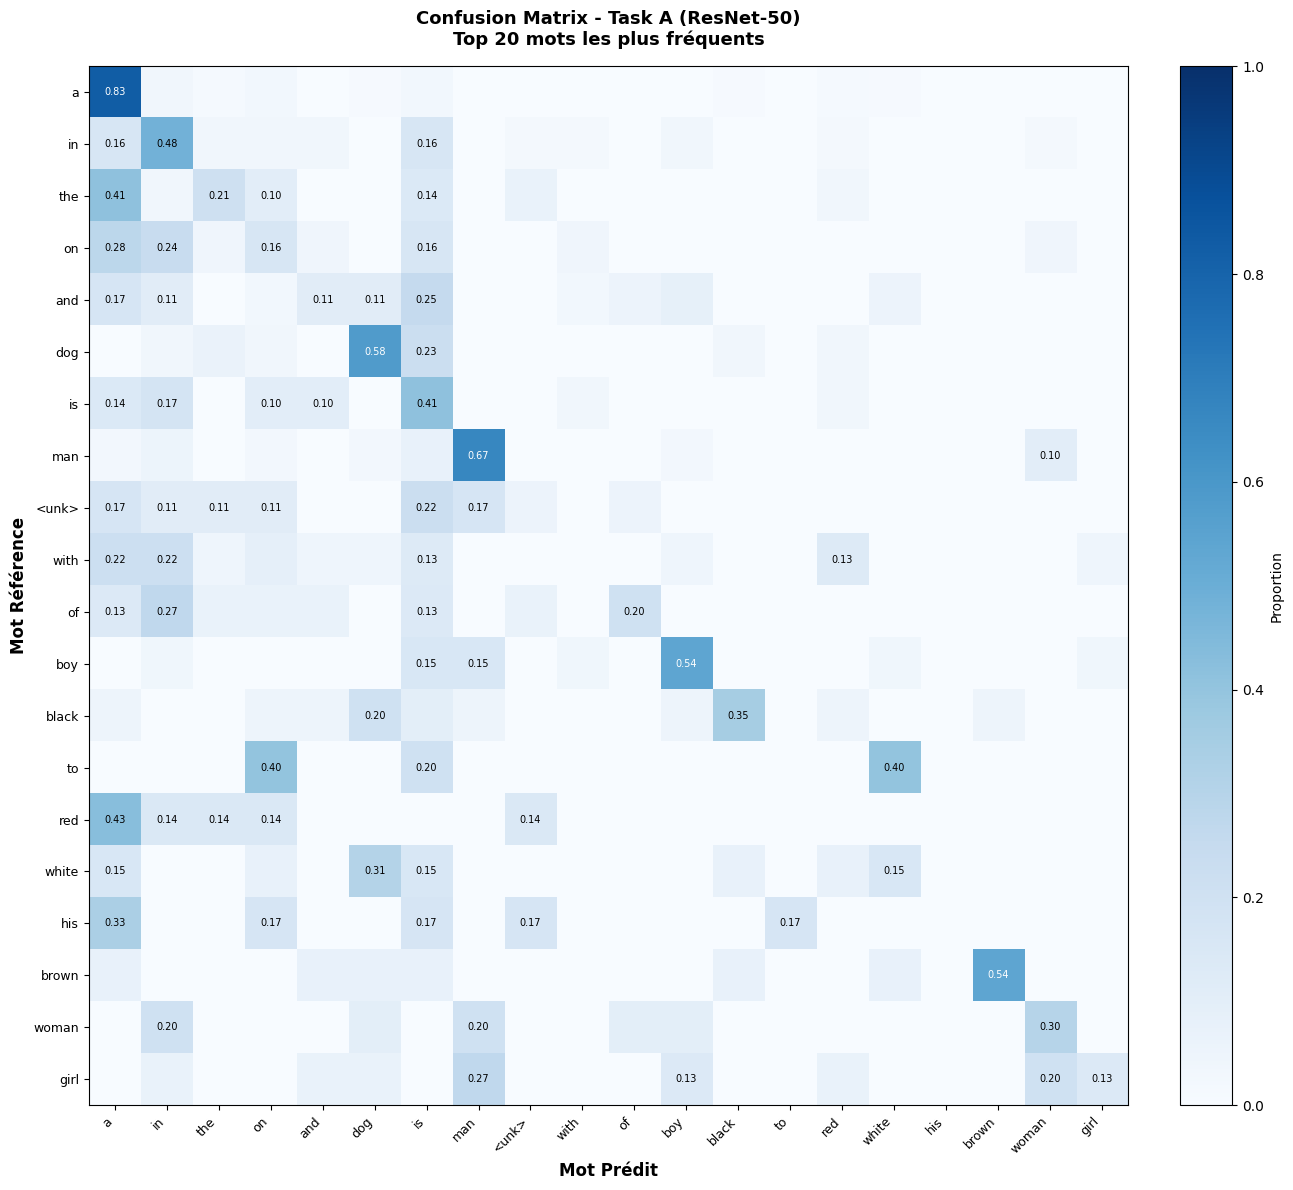

✅ Sauvegardée : /content/confusion_matrix_taskA.png

🟢 Confusion Matrix - Task B (Custom CNN)


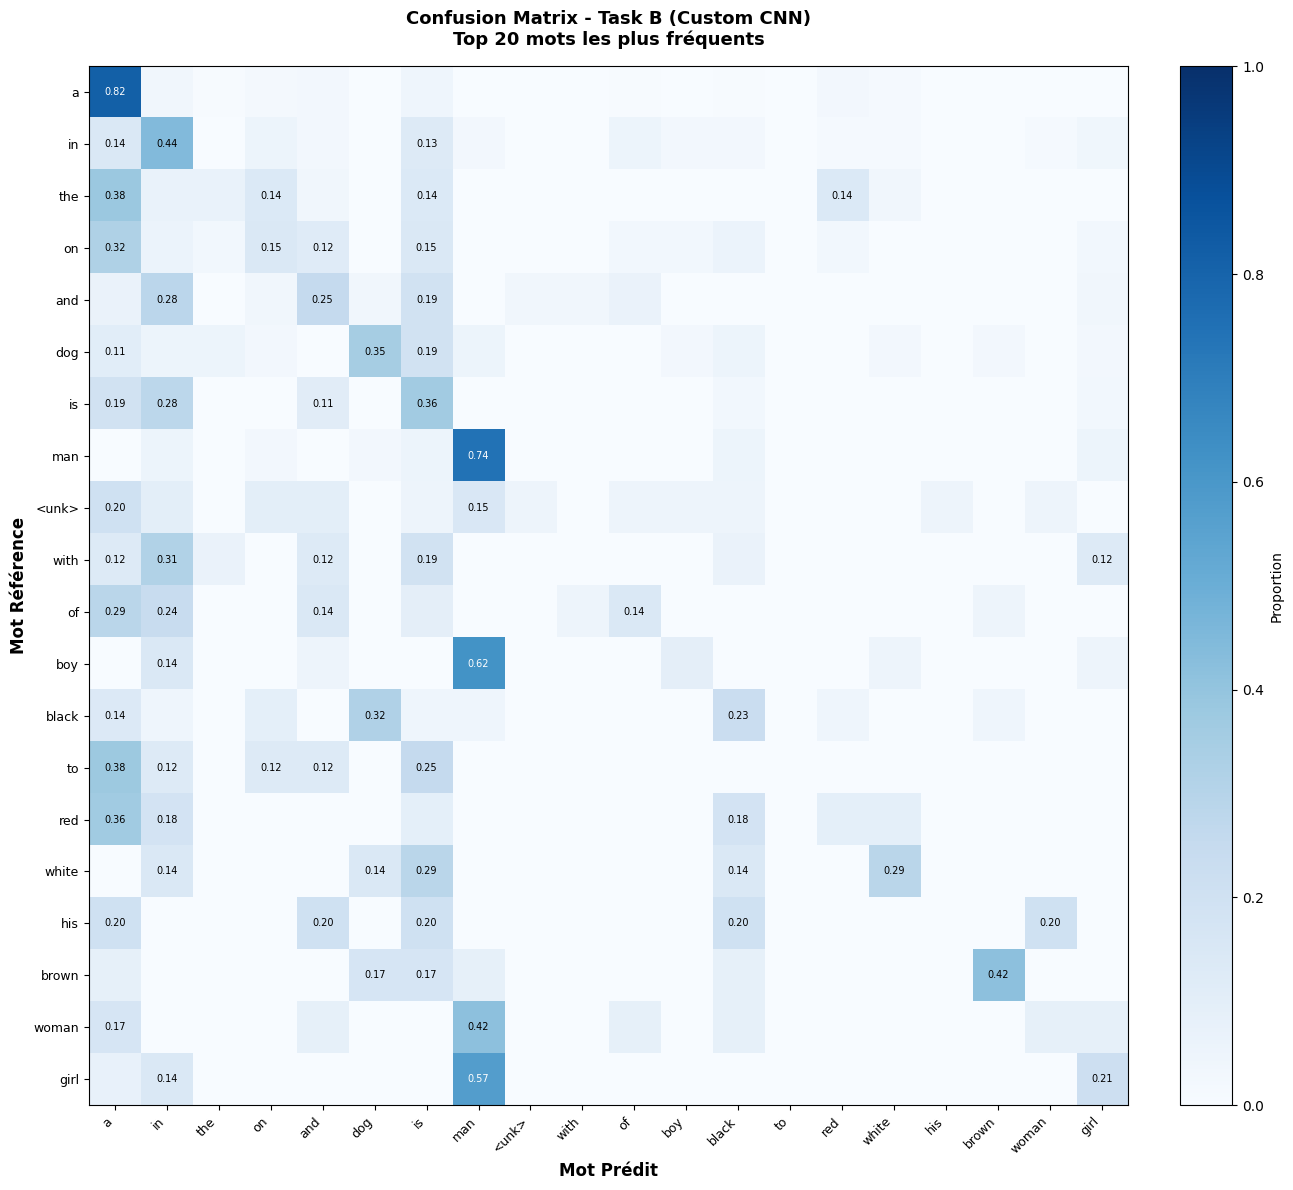

✅ Sauvegardée : /content/confusion_matrix_taskB.png

✅ CONFUSION MATRICES GÉNÉRÉES ET SAUVEGARDÉES !

📊 Lecture de la matrice :
   - Ligne   = mot de RÉFÉRENCE (attendu)
   - Colonne = mot PRÉDIT par le modèle
   - Diagonal brillant = bonne prédiction ✅
   - Hors diagonal     = confusion entre mots ❌

💡 Task A devrait avoir une diagonale plus marquée (meilleure précision)



In [ ]:

# CONFUSION MATRIX - TASK E

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pickle

print("=" * 70)
print("📊 GÉNÉRATION DES CONFUSION MATRICES")
print("=" * 70)

# CHARGER LES MODÈLES
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

drive_path = '/content/drive/MyDrive/Apprentissage/TP2_Groupe3/'

checkpoint_A = torch.load(f'{drive_path}best_model_taskA.pth', map_location=device)
model.load_state_dict(checkpoint_A['model_state_dict'])
model.eval()

checkpoint_B = torch.load(f'{drive_path}best_model_taskB.pth', map_location=device)
model_custom.load_state_dict(checkpoint_B['model_state_dict'])
model_custom.eval()

print("✅ Modèles chargés")


# FONCTION DE GÉNÉRATION DE CAPTION
def generate_caption_tokens(model, image, max_len=20, is_custom=False):
    """Génère une caption et retourne les tokens prédits"""
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(device)

        # Encoder
        if is_custom:
            features, _ = model.encoder(image)
        else:
            features = model.encoder(image)

        # Préparer les features pour le decoder
        batch_size = 1
        encoder_dim = features.size(1)
        num_pixels = features.size(2) * features.size(3)

        features_flat = features.view(batch_size, encoder_dim, -1).permute(0, 2, 1)

        # Init hidden state
        mean_features = features_flat.mean(dim=1)
        h = model.decoder.init_h(mean_features)
        c = model.decoder.init_c(mean_features)

        # Génération mot par mot
        word_idx = word2idx['<start>']
        predicted_tokens = []

        for _ in range(max_len):
            embedding = model.decoder.embedding(
                torch.tensor([word_idx]).to(device)
            )
            context, _ = model.decoder.attention(features_flat, h)
            lstm_input = torch.cat([embedding, context], dim=1)
            h, c = model.decoder.lstm_cell(lstm_input, (h, c))
            output = model.decoder.fc(h)
            word_idx = output.argmax(dim=1).item()

            if word_idx == word2idx['<end>']:
                break
            predicted_tokens.append(word_idx)

    return predicted_tokens


# COLLECTER PRÉDICTIONS SUR 200 IMAGES DU TEST SET
print("\n⏳ Génération des captions sur 200 images test...")

N_SAMPLES = 200
predicted_A = []
predicted_B = []
references  = []

# Prendre les N premières images uniques du test set
test_images_list = df_test['image'].unique()[:N_SAMPLES]

for img_name in test_images_list:
    row = df_test[df_test['image'] == img_name].iloc[0]

    # Charger l'image
    from PIL import Image
    img = Image.open(f'/content/data/Images/{img_name}').convert('RGB')
    img_tensor = val_transform(img)

    # Référence (tokens réels, sans <start> et <end>)
    ref_tokens = [t for t in row['tokens']
                  if t not in [word2idx['<pad>'], word2idx['<start>'], word2idx['<end>']]]
    references.append(ref_tokens)

    # Prédiction Task A
    tokens_A = generate_caption_tokens(model, img_tensor, is_custom=False)
    predicted_A.append(tokens_A)

    # Prédiction Task B
    tokens_B = generate_caption_tokens(model_custom, img_tensor, is_custom=True)
    predicted_B.append(tokens_B)

print(f"✅ {N_SAMPLES} captions générées pour chaque modèle")


# CONSTRUIRE LA MATRICE DE CONFUSION
def build_confusion_matrix(references, predictions, top_n=20):
    """
    Matrice de confusion : pour chaque position,
    compare mot prédit vs mot référence
    """
    # Trouver les top N mots dans les références
    all_ref = [tok for ref in references for tok in ref]
    word_freq = Counter(all_ref)
    top_tokens = [tok for tok, _ in word_freq.most_common(top_n)]
    tok_to_idx = {tok: i for i, tok in enumerate(top_tokens)}

    # Construire la matrice
    matrix = np.zeros((top_n, top_n), dtype=int)

    for ref, pred in zip(references, predictions):
        for r_tok, p_tok in zip(ref, pred):
            if r_tok in tok_to_idx and p_tok in tok_to_idx:
                r_idx = tok_to_idx[r_tok]
                p_idx = tok_to_idx[p_tok]
                matrix[r_idx][p_idx] += 1

    # Labels lisibles
    labels = [idx2word[tok] for tok in top_tokens]
    return matrix, labels


def plot_confusion_matrix(matrix, labels, title, save_path):
    """Affiche et sauvegarde la matrice de confusion"""
    fig, ax = plt.subplots(figsize=(14, 12))

    # Normaliser par ligne
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix_norm = np.divide(matrix.astype(float), row_sums,
                            where=row_sums != 0)

    im = ax.imshow(matrix_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Proportion')

    tick_marks = np.arange(len(labels))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)

    # Afficher les valeurs dans les cases
    for i in range(len(labels)):
        for j in range(len(labels)):
            if matrix_norm[i, j] > 0.1:
                ax.text(j, i, f'{matrix_norm[i,j]:.2f}',
                       ha='center', va='center', fontsize=7,
                       color='white' if matrix_norm[i, j] > 0.5 else 'black')

    ax.set_ylabel('Mot Référence', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mot Prédit', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Sauvegardée : {save_path}")


# GÉNÉRER LES DEUX MATRICES
TOP_N = 20

print("\n🔵 Confusion Matrix - Task A (ResNet-50)")
matrix_A, labels_A = build_confusion_matrix(references, predicted_A, top_n=TOP_N)
plot_confusion_matrix(
    matrix_A, labels_A,
    f'Confusion Matrix - Task A (ResNet-50)\nTop {TOP_N} mots les plus fréquents',
    '/content/confusion_matrix_taskA.png'
)

print("\n🟢 Confusion Matrix - Task B (Custom CNN)")
matrix_B, labels_B = build_confusion_matrix(references, predicted_B, top_n=TOP_N)
plot_confusion_matrix(
    matrix_B, labels_B,
    f'Confusion Matrix - Task B (Custom CNN)\nTop {TOP_N} mots les plus fréquents',
    '/content/confusion_matrix_taskB.png'
)


# SAUVEGARDER SUR DRIVE
import shutil
drive_path = '/content/drive/MyDrive/Apprentissage/TP2_Groupe3/'

shutil.copy('/content/confusion_matrix_taskA.png', f'{drive_path}confusion_matrix_taskA.png')
shutil.copy('/content/confusion_matrix_taskB.png', f'{drive_path}confusion_matrix_taskB.png')

print("\n" + "=" * 70)
print("✅ CONFUSION MATRICES GÉNÉRÉES ET SAUVEGARDÉES !")
print("=" * 70)
print("""
📊 Lecture de la matrice :
   - Ligne   = mot de RÉFÉRENCE (attendu)
   - Colonne = mot PRÉDIT par le modèle
   - Diagonal brillant = bonne prédiction
   - Hors diagonal     = confusion entre mots

💡 Task A devrait avoir une diagonale plus marquée (meilleure précision)
""")

In [ ]:
import os
drive_path = '/content/drive/MyDrive/Apprentissage/TP2_Groupe3/'

for f in os.listdir(drive_path):
    if 'confusion' in f:
        size = os.path.getsize(f'{drive_path}{f}') / 1024
        print(f"✅ {f} ({size:.0f} KB)")

✅ confusion_matrix_taskA.png (134 KB)
✅ confusion_matrix_taskB.png (134 KB)


In [ ]:

#VISUALISATION DES ATTENTION HEATMAPS - TASK C

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import cv2
from torchvision import transforms

print("=" * 70)
print("👁️ GÉNÉRATION DES ATTENTION HEATMAPS")
print("=" * 70)

def visualize_attention(image_path, caption, alphas, save_path=None):
    """
    Visualise les attention heatmaps pour chaque mot de la caption

    Args:
        image_path: Chemin vers l'image originale
        caption: Liste de mots générés
        alphas: Liste des attention weights (num_words, 49)
        save_path: Chemin pour sauvegarder la figure
    """
    # Charger l'image originale
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)

    # Nombre de mots à afficher (max 6 pour lisibilité)
    num_words = min(len(caption), 6)

    # Créer la figure
    fig, axes = plt.subplots(2, num_words, figsize=(3*num_words, 6))
    if num_words == 1:
        axes = axes.reshape(2, 1)

    for idx in range(num_words):
        # Image originale
        axes[0, idx].imshow(img_array)
        axes[0, idx].axis('off')
        axes[0, idx].set_title(f'Word: "{caption[idx]}"', fontsize=10)

        # Attention heatmap
        alpha = alphas[idx].reshape(7, 7)  # (49,) -> (7, 7)

        # Resize à la taille de l'image
        alpha_resized = cv2.resize(alpha, (img_array.shape[1], img_array.shape[0]))

        # Superposer
        axes[1, idx].imshow(img_array)
        axes[1, idx].imshow(alpha_resized, cmap='jet', alpha=0.6)
        axes[1, idx].axis('off')
        axes[1, idx].set_title(f'Attention', fontsize=10)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

print("✅ Fonction visualize_attention créée")


def generate_attention_examples(model, image_names, word2idx, idx2word, device, num_examples=3, task_name='A'):
    """
    Génère des exemples de visualisation d'attention

    Args:
        model: Modèle d'image captioning
        image_names: Liste de noms de fichiers d'images
        word2idx, idx2word: Vocabulaire
        device: Device
        num_examples: Nombre d'exemples
        task_name: 'A' ou 'B'
    """
    images_dir = '/content/data/Images'

    # Transformation pour l'image
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    for i, img_name in enumerate(image_names[:num_examples]):
        print(f"\n{'='*70}")
        print(f"Exemple {i+1} - {img_name}")
        print('='*70)

        img_path = f"{images_dir}/{img_name}"

        # Charger et transformer l'image
        img = Image.open(img_path).convert('RGB')
        img_tensor = transform(img).unsqueeze(0)

        # Générer caption avec attention
        caption, alphas = generate_caption(
            model, img_tensor, word2idx, idx2word, device=device
        )

        print(f"Caption générée : {' '.join(caption)}")

        # Convertir alphas en numpy array
        alphas = np.array(alphas)

        # Visualiser
        save_path = f'/content/attention_task{task_name}_example{i+1}.png'
        visualize_attention(img_path, caption, alphas, save_path=save_path)

        print(f"✅ Sauvegardé : {save_path}")

print("✅ Fonction generate_attention_examples créée")
print()

# ====== SÉLECTIONNER DES IMAGES DU TEST SET ======
print("=" * 70)
print("🎨 GÉNÉRATION DES EXEMPLES D'ATTENTION")
print("=" * 70)

# Récupérer quelques noms d'images du test set
test_image_names = []
for batch in test_loader:
    test_image_names.extend(batch['image_name'])
    if len(test_image_names) >= 10:
        break

# Prendre 3 exemples
# sample_image_names = test_image_names[:3]
sample_image_names = list(set(test_image_names))[:3]

print(f"\nImages sélectionnées :")
for name in sample_image_names:
    print(f"  - {name}")

# GÉNÉRER POUR TASK A
print("\n🔵 TASK A - ResNet-50")
generate_attention_examples(
    model, sample_image_names, word2idx, idx2word,
    device, num_examples=3, task_name='A'
)

# GÉNÉRER POUR TASK B
print("\n\n🟢 TASK B - Custom CNN")
generate_attention_examples(
    model_custom, sample_image_names, word2idx, idx2word,
    device, num_examples=3, task_name='B'
)

print("\n" + "=" * 70)
print("✅ ATTENTION HEATMAPS GÉNÉRÉES !")
print("=" * 70)
print("\n📁 Fichiers sauvegardés :")
print("  Task A :")
for i in range(1, 4):
    print(f"    - attention_taskA_example{i}.png")
print("  Task B :")
for i in range(1, 4):
    print(f"    - attention_taskB_example{i}.png")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

# GRAD-CAM POUR CUSTOM CNN - TASK C

import torch
import torch.nn.functional as F
import cv2

print("=" * 70)
print("🎨 GRAD-CAM POUR CUSTOM CNN")
print("=" * 70)

class GradCAM:
    """Grad-CAM pour visualiser les zones importantes"""
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, image, target_layer):
        """Génère la CAM"""
        forward_handle = target_layer.register_forward_hook(self.forward_hook)
        backward_handle = target_layer.register_full_backward_hook(self.backward_hook)

        # Forward
        self.model.eval()
        encoder_output = self.model.encoder(image)

        # Gérer le tuple (Task B retourne (features, gap_out))
        if isinstance(encoder_output, tuple):
            output = encoder_output[0]
        else:
            output = encoder_output

        # Backward
        self.model.zero_grad()
        output.mean().backward()

        # Calculer CAM
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()

        # Normaliser
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        # Resize
        cam = cam.cpu().numpy()
        cam = cv2.resize(cam, (224, 224))

        # Cleanup
        forward_handle.remove()
        backward_handle.remove()

        return cam

print("✅ Classe GradCAM créée")


def visualize_gradcam(model, image_path, save_path=None):
    """Visualise Grad-CAM"""
    img = Image.open(image_path).convert('RGB')
    img_array = np.array(img)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0).to(device)

    # Générer CAM
    gradcam = GradCAM(model)
    cam = gradcam.generate_cam(img_tensor, model.encoder.conv5)

    # Visualiser
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_array)
    axes[0].set_title('Image originale', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(cam, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12)
    axes[1].axis('off')

    img_resized = cv2.resize(img_array, (224, 224))
    axes[2].imshow(img_resized)
    axes[2].imshow(cam, cmap='jet', alpha=0.5)
    axes[2].set_title('Superposition', fontsize=12)
    axes[2].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

print("✅ Fonction visualize_gradcam créée")
print()

# GÉNÉRER GRAD-CAM
print("=" * 70)
print("🎨 GÉNÉRATION DES GRAD-CAM")
print("=" * 70)

drive_path = '/content/drive/MyDrive/Apprentissage/TP2_Groupe3/'

unique_images = list(set(test_image_names))[:3]

for i, img_name in enumerate(unique_images):
    print(f"\nExemple {i+1} : {img_name}")
    img_path = f"/content/data/Images/{img_name}"
    save_path = f"{drive_path}gradcam_example{i+1}.png"

    visualize_gradcam(model_custom, img_path, save_path=save_path)
    print(f"Sauvegardé : {save_path}")

print("\n" + "=" * 70)
print("GRAD-CAM GÉNÉRÉS !")
print("=" * 70)

Output hidden; open in https://colab.research.google.com to view.

📸 GÉNÉRATION DE LA GALERIE DE RÉSULTATS
✅ Fonction create_result_gallery créée

🎨 GÉNÉRATION DE LA GALERIE (5 IMAGES)

Images sélectionnées :
  - 1057089366_ca83da0877.jpg
  - 1007129816_e794419615.jpg
  - 1019077836_6fc9b15408.jpg
  - 1022454428_b6b660a67b.jpg
  - 103195344_5d2dc613a3.jpg



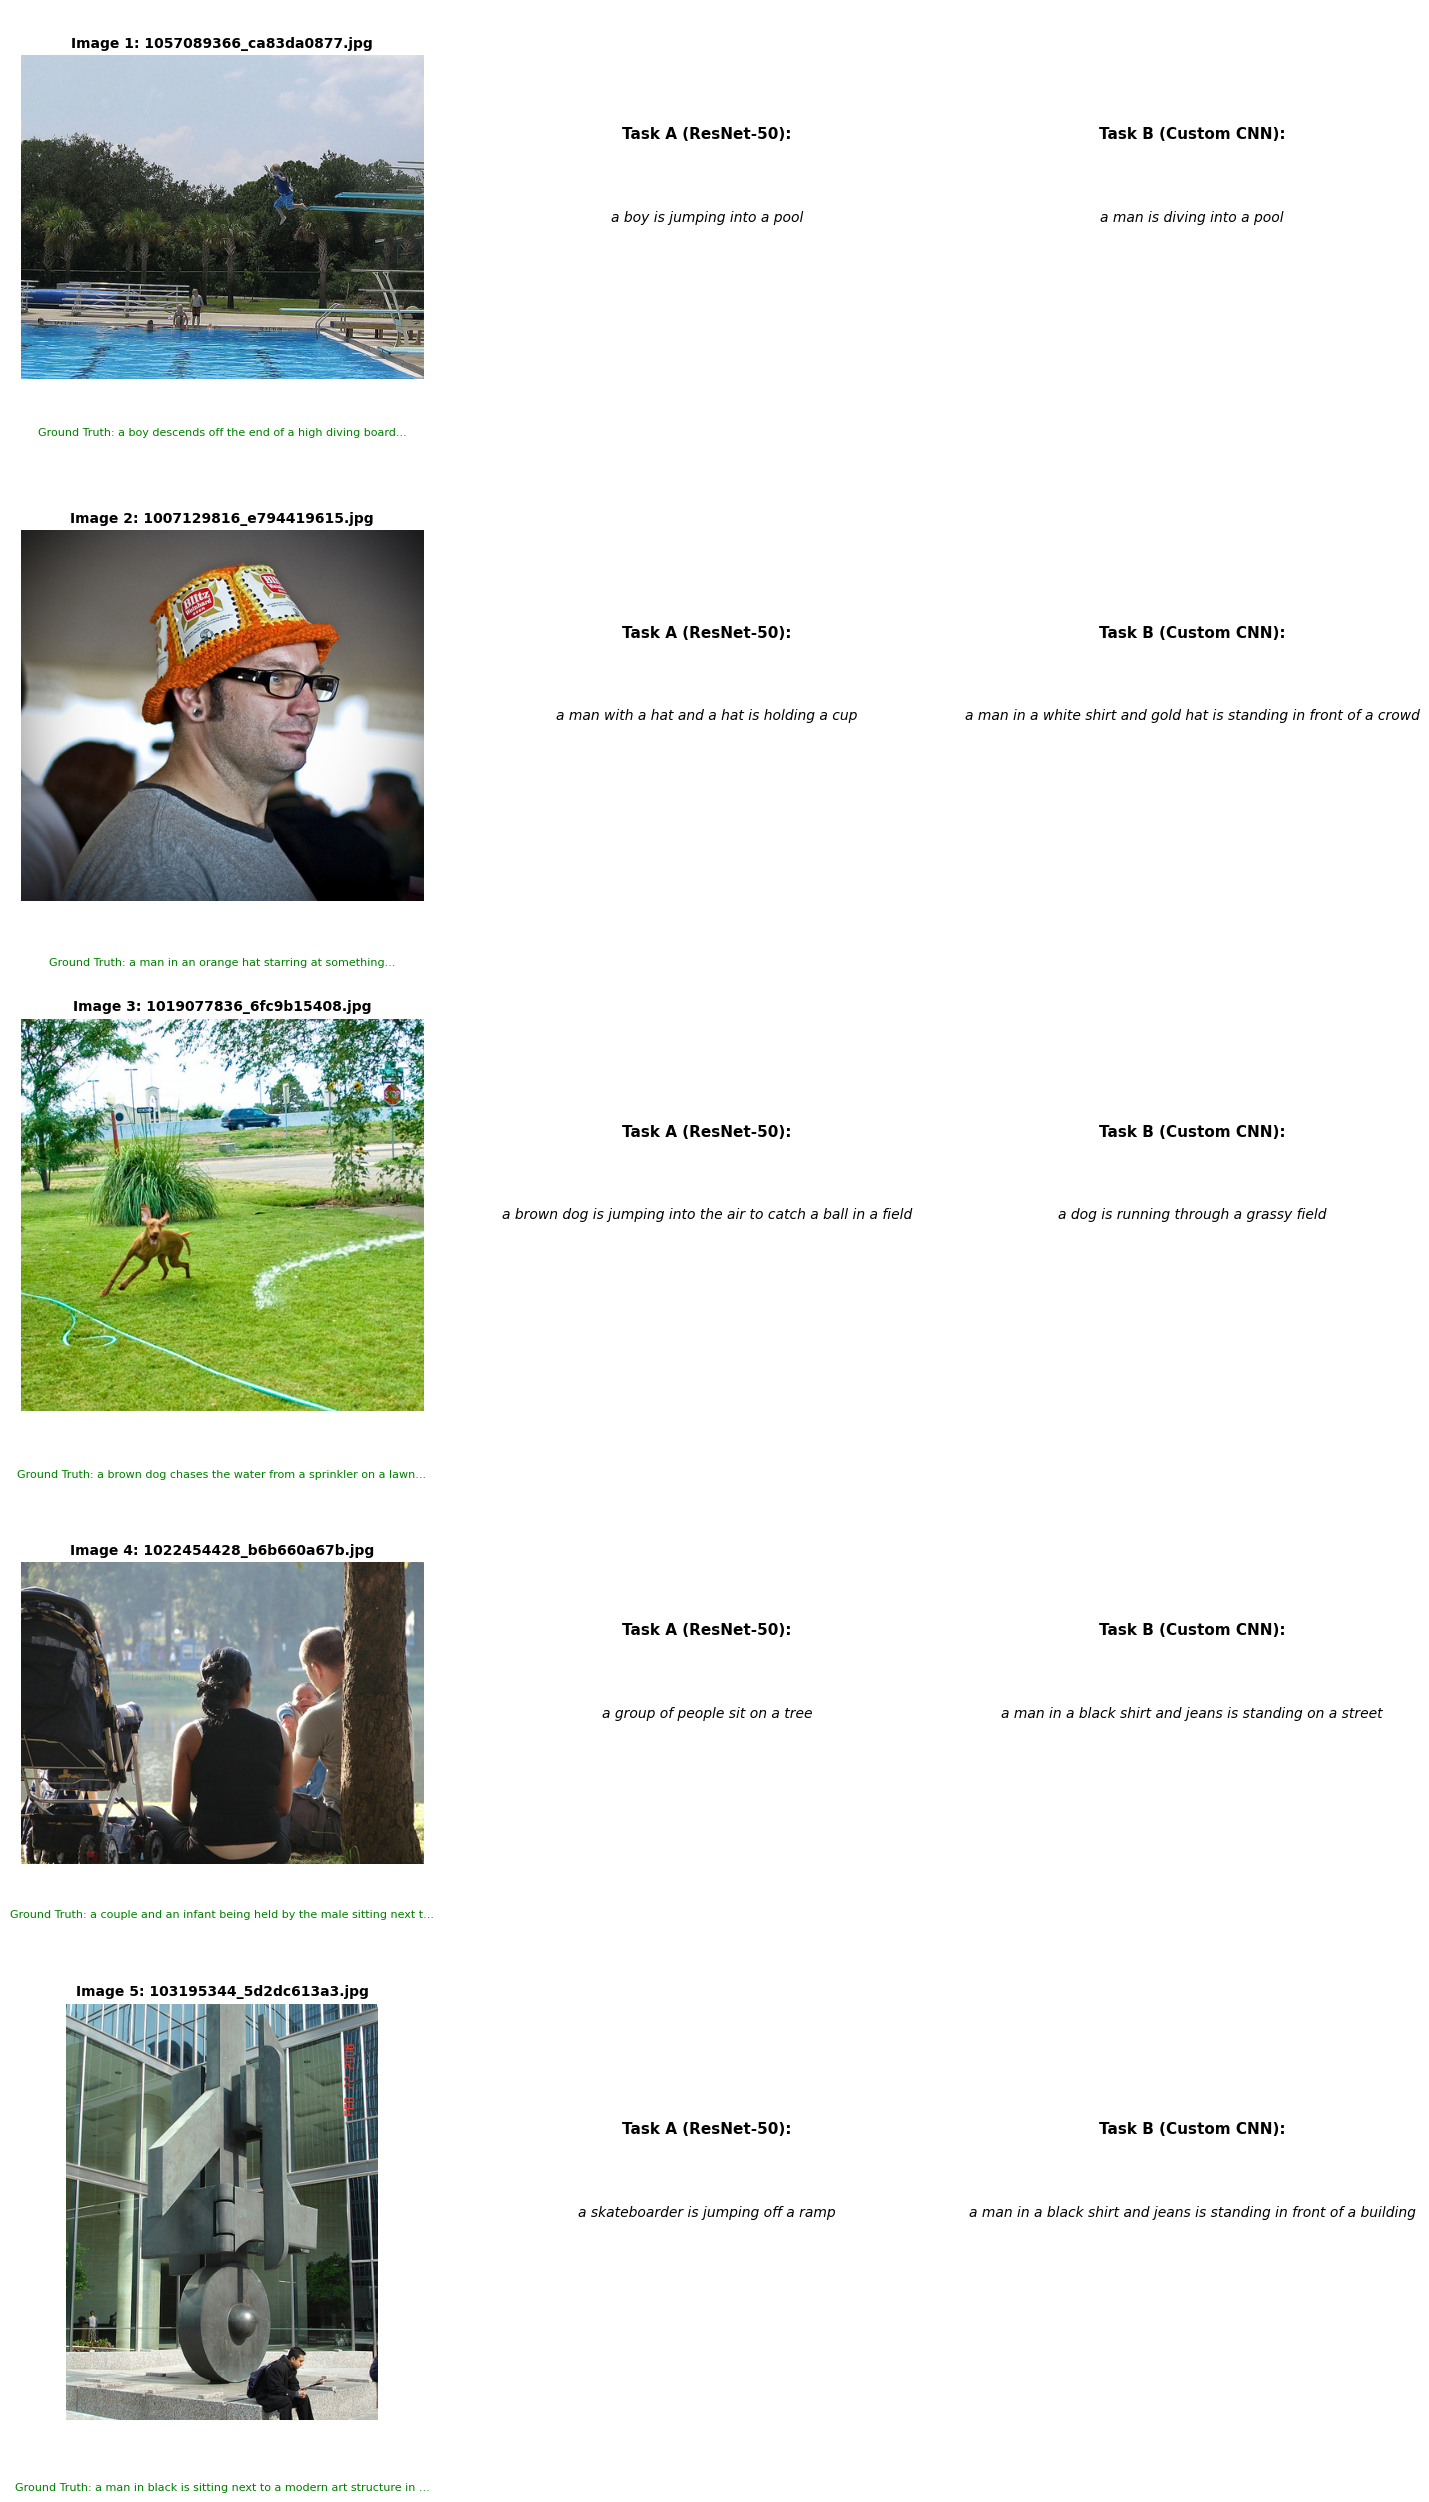


✅ Galerie sauvegardée : /content/result_gallery.png

✅ GALERIE DE RÉSULTATS COMPLÈTE !


In [ ]:

# GALERIE DE RÉSULTATS - TASK E

print("=" * 70)
print("📸 GÉNÉRATION DE LA GALERIE DE RÉSULTATS")
print("=" * 70)

def create_result_gallery(model_A, model_B, image_names, word2idx, idx2word, device, num_images=5):
    """
    Crée une galerie comparative des résultats
    """
    images_dir = '/content/data/Images'

    # Transformation
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Créer la figure
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5*num_images))

    for i, img_name in enumerate(image_names[:num_images]):
        img_path = f"{images_dir}/{img_name}"

        # Charger l'image
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img)
        img_tensor = transform(img).unsqueeze(0)

        # Générer captions
        caption_A, _ = generate_caption(model_A, img_tensor, word2idx, idx2word, device=device)
        caption_B, _ = generate_caption(model_B, img_tensor, word2idx, idx2word, device=device)

        # Ground truth (récupérer depuis le dataset)
        gt_captions = df_test[df_test['image'] == img_name]['caption_clean'].head(1).values
        gt_text = gt_captions[0] if len(gt_captions) > 0 else "N/A"

        # Afficher l'image originale (colonne 1)
        axes[i, 0].imshow(img_array)
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f'Image {i+1}: {img_name}', fontsize=10, fontweight='bold')

        # Task A caption (colonne 2)
        axes[i, 1].text(0.5, 0.7, f"Task A (ResNet-50):",
                       ha='center', va='center', fontsize=11, fontweight='bold',
                       transform=axes[i, 1].transAxes)
        axes[i, 1].text(0.5, 0.5, ' '.join(caption_A),
                       ha='center', va='center', fontsize=10, style='italic',
                       transform=axes[i, 1].transAxes, wrap=True)
        axes[i, 1].axis('off')

        # Task B caption (colonne 3)
        axes[i, 2].text(0.5, 0.7, f"Task B (Custom CNN):",
                       ha='center', va='center', fontsize=11, fontweight='bold',
                       transform=axes[i, 2].transAxes)
        axes[i, 2].text(0.5, 0.5, ' '.join(caption_B),
                       ha='center', va='center', fontsize=10, style='italic',
                       transform=axes[i, 2].transAxes, wrap=True)
        axes[i, 2].axis('off')

        # Afficher le ground truth en bas de chaque image
        axes[i, 0].text(0.5, -0.15, f"Ground Truth: {gt_text[:60]}...",
                       ha='center', va='top', fontsize=8, color='green',
                       transform=axes[i, 0].transAxes, wrap=True)

    plt.tight_layout()
    plt.savefig('/content/result_gallery.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✅ Galerie sauvegardée : /content/result_gallery.png")

print("✅ Fonction create_result_gallery créée")
print()

print("=" * 70)
print("🎨 GÉNÉRATION DE LA GALERIE (5 IMAGES)")
print("=" * 70)

# Prendre 5 images UNIQUES
unique_test_images = list(set(test_image_names))[:5]

print(f"\nImages sélectionnées :")
for img in unique_test_images:
    print(f"  - {img}")

print()
create_result_gallery(
    model, model_custom,
    unique_test_images,
    word2idx, idx2word,
    device, num_images=5
)

print("\n" + "=" * 70)
print("✅ GALERIE DE RÉSULTATS COMPLÈTE !")
print("=" * 70)